In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import re

In [38]:
# Define all subdirectories in ryddet
ryddet_base = Path('ryddet')

subdirs = {
    'base_linux': ryddet_base / 'base_linux',
    'base_unikernel': ryddet_base / 'base_unikernel',
    'optimized_linux_iso_eist_c-state_off': ryddet_base / 'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off': ryddet_base / 'optimized_linux_wo_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_on': ryddet_base / 'optimized_linux_wo_iso_eist_c-state_on',
    'optimized_unikernel': ryddet_base / 'otimized_unikernel',  # Note: typo in directory name
    'naive_linux': ryddet_base / 'naive_linux',
}

config_labels = {
    'naive_linux': 'Linux Naive',
    'base_linux': 'Linux Base',
    'optimized_linux_iso_eist_c-state_off': 'Linux Opt + Isolation',
    'optimized_linux_wo_iso_eist_c-state_off': 'Linux Opt',
    'optimized_linux_wo_iso_eist_c-state_on': 'Linux Opt (C-state On)',
    'base_unikernel': 'Unikernel Base',
    'optimized_unikernel': 'Unikernel Opt',
}

print("Available subdirectories:")
for name, path in subdirs.items():
    pretty = config_labels.get(name, name)
    print(f"  {pretty}: {path}")

Available subdirectories:
  Linux Base: ryddet/base_linux
  Unikernel Base: ryddet/base_unikernel
  Linux Opt + Isolation: ryddet/optimized_linux_iso_eist_c-state_off
  Linux Opt: ryddet/optimized_linux_wo_iso_eist_c-state_off
  Linux Opt (C-state On): ryddet/optimized_linux_wo_iso_eist_c-state_on
  Unikernel Opt: ryddet/otimized_unikernel
  Linux Naive: ryddet/naive_linux


In [39]:
# Load powermeter measurements (binary_output_*.log files)
powermeter_data = {}

for name, path in subdirs.items():
    powermeter_data[name] = {}
    
    # Get all .log files in the directory
    log_files = sorted(path.glob('binary_output_*.log'))
    
    for log_file in log_files:
        # Extract benchmark name and iteration number from filename
        # e.g., binary_output_crc32_0.log -> benchmark=crc32, iteration=0
        match = re.match(r'binary_output_(.+)_(\d+)\.log', log_file.name)
        if match:
            benchmark = match.group(1)
            iteration = int(match.group(2))
            
            # Initialize benchmark dict if needed
            if benchmark not in powermeter_data[name]:
                powermeter_data[name][benchmark] = {}
            
            # Load the log file
            try:
                df = pd.read_csv(log_file)
                powermeter_data[name][benchmark][iteration] = df
            except Exception as e:
                print(f"Error loading {log_file}: {e}")

# Print summary
print("Powermeter data summary:")
for config_name, benchmarks in powermeter_data.items():
    total_files = sum(len(iterations) for iterations in benchmarks.values())
    print(f"  {config_name}: {len(benchmarks)} benchmarks, {total_files} total files")

Error loading ryddet/optimized_linux_wo_iso_eist_c-state_off/binary_output_cubic_5.log: No columns to parse from file
Error loading ryddet/otimized_unikernel/binary_output_crc32_1.log: No columns to parse from file
Error loading ryddet/otimized_unikernel/binary_output_cubic_10.log: No columns to parse from file
Error loading ryddet/naive_linux/binary_output_dijkstra_10.log: No columns to parse from file
Powermeter data summary:
  base_linux: 9 benchmarks, 450 total files
  base_unikernel: 9 benchmarks, 450 total files
  optimized_linux_iso_eist_c-state_off: 9 benchmarks, 450 total files
  optimized_linux_wo_iso_eist_c-state_off: 9 benchmarks, 449 total files
  optimized_linux_wo_iso_eist_c-state_on: 9 benchmarks, 450 total files
  optimized_unikernel: 9 benchmarks, 448 total files
  naive_linux: 9 benchmarks, 449 total files


In [40]:
# Display sample powermeter data
config = 'base_linux'
benchmark = 'crc32'
iteration = 0

if config in powermeter_data and benchmark in powermeter_data[config]:
    if iteration in powermeter_data[config][benchmark]:
        print(f"Sample powermeter data from {config} / {benchmark} / iteration {iteration}:")
        print(powermeter_data[config][benchmark][iteration].head(10))
        print(f"\nShape: {powermeter_data[config][benchmark][iteration].shape}")
    else:
        print(f"Iteration {iteration} not found")
else:
    print(f"Config or benchmark not found")

Sample powermeter data from base_linux / crc32 / iteration 0:
     unix_timestamp  active_power (mW)
0  1769679226797480              49380
1  1769679226840548              30650
2  1769679226883642              47620
3  1769679226926374              45280
4  1769679226969460              44590
5  1769679227012621              44700
6  1769679227055736              44710
7  1769679227100474              44770
8  1769679227143607              44910
9  1769679227186615              44770

Shape: (393, 2)


In [41]:
# Display structure of powermeter data
print("Benchmarks found per configuration:")
for config_name, benchmarks in powermeter_data.items():
    benchmark_list = sorted(benchmarks.keys())
    iterations = [len(benchmarks[b]) for b in benchmark_list]
    print(f"\n{config_name}:")
    print(f"  Benchmarks: {benchmark_list}")
    print(f"  Iterations per benchmark: {iterations[0] if iterations else 0} (first benchmark)")

Benchmarks found per configuration:

base_linux:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

base_unikernel:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

optimized_linux_iso_eist_c-state_off:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

optimized_linux_wo_iso_eist_c-state_off:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

optimized_linux_wo_iso_eist_c-state_on:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iteration

In [42]:
# Load PC measurements (unikernel_output.csv from each directory)
pc_data = {}

for name, path in subdirs.items():
    csv_file = path / 'unikernel_output.csv'
    if csv_file.exists():
        df = pd.read_csv(csv_file)
        pc_data[name] = df
        print(f"Loaded {name}: {len(df)} rows, {len(df.columns)} columns")
    else:
        print(f"Warning: {csv_file} not found")

print(f"\nTotal configurations loaded: {len(pc_data)}")

Loaded base_linux: 450 rows, 21 columns
Loaded base_unikernel: 450 rows, 21 columns
Loaded optimized_linux_iso_eist_c-state_off: 450 rows, 21 columns
Loaded optimized_linux_wo_iso_eist_c-state_off: 450 rows, 21 columns
Loaded optimized_linux_wo_iso_eist_c-state_on: 450 rows, 21 columns
Loaded optimized_unikernel: 451 rows, 21 columns
Loaded naive_linux: 450 rows, 21 columns

Total configurations loaded: 7


In [43]:
# Display sample PC data for one configuration
print("Sample PC data from base_linux:")
print(pc_data['base_linux'].head())

Sample PC data from base_linux:
  benchmark   cpu_cycles   cycles_start     cycles_end       time_ns  \
0     crc32  52264844388  2744974811597  2797239655985  1.689800e+10   
1     crc32  52260900301  2797240059066  2849500959367  1.689672e+10   
2     crc32  52272654002  2849501249129  2901773903131  1.690052e+10   
3     crc32  52263599416  2901774319665  2954037919081  1.689759e+10   
4     crc32  52271811460  2954038206271  3006310017731  1.690024e+10   

        time_ms  cooldown_ms  temp_before  temp_after  pkg_temp_before  ...  \
0  16898.003169       20.288         45.0        43.0             45.0  ...   
1  16896.718633        0.010         43.0        43.0             43.0  ...   
2  16900.515695        0.009         43.0        44.0             43.0  ...   
3  16897.591201        0.009         44.0        44.0             44.0  ...   
4  16900.241563        0.009         44.0        44.0             44.0  ...   

   pkg_joules      pkg_mJ  pp0_joules      pp0_mJ  pp1_joule

In [44]:
# Calculate energy consumption from powermeter data and compare with pkg energy
# Energy = Average Power (W) × Time (s)

energy_results = []

for config_name in subdirs.keys():
    # Get PC data for this config
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    
    # Get unique benchmarks from PC data
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get PC measurements for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        # Skip if no data found for this benchmark
        if len(pc_bench) == 0:
            continue
        
        # Calculate mean and std for pkg energy from PC data (in Joules)
        pkg_energies = pc_bench['pkg_joules'].values
        mean_pkg_joules = pkg_energies.mean()
        std_pkg_joules = pkg_energies.std()
        mean_time_ms = pc_bench['cpu_cycles'].mean() / 3.1e6  # Convert cycles to ms at 3.1 GHz
        
        # Calculate energy from powermeter data if available
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            powermeter_energies = []
            
            for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                # Skip empty or very small DataFrames (need at least 2 points for time span)
                if len(pm_df) < 2:
                    continue
                
                # Skip if iteration index is out of bounds
                if iteration >= len(pc_bench):
                    continue
                    
                # Get average power in Watts (convert mW to W)
                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                
                # Get time span from CPU cycles
                cpu_cycles = pc_bench.iloc[iteration]['cpu_cycles']
                time_span_s = cpu_cycles / 3.1e9  # Convert cycles to seconds at 3.1 GHz
                
                # Calculate energy in Joules
                energy_j = avg_power_w * time_span_s
                powermeter_energies.append(energy_j)
            
            mean_powermeter_energy = np.mean(powermeter_energies) if powermeter_energies else None
            std_powermeter_energy = np.std(powermeter_energies) if powermeter_energies else None
        else:
            mean_powermeter_energy = None
            std_powermeter_energy = None
        
        energy_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pkg_energy_j': mean_pkg_joules,
            'pkg_energy_std': std_pkg_joules,
            'powermeter_energy_j': mean_powermeter_energy,
            'powermeter_energy_std': std_powermeter_energy,
            'time_ms': mean_time_ms
        })

# Convert to DataFrame for easier plotting
energy_df = pd.DataFrame(energy_results)
print(f"Energy analysis ready: {len(energy_df)} benchmark-config combinations")
print(energy_df.head(10))

Energy analysis ready: 63 benchmark-config combinations
           config      benchmark  pkg_energy_j  pkg_energy_std  \
0      base_linux          crc32    328.745854       65.573856   
1      base_linux          cubic    303.501435        0.274130   
2      base_linux       dijkstra    364.126380        0.624894   
3      base_linux           fdct    292.324112        1.691322   
4      base_linux            fir    249.244443        0.148380   
5      base_linux  matmult-float    334.835891        0.272198   
6      base_linux    matmult-int    309.250208        1.767003   
7      base_linux  nettle-sha256    396.754678        0.255770   
8      base_linux       rijndael    338.380310        0.224704   
9  base_unikernel          crc32    264.171602        0.543096   

   powermeter_energy_j  powermeter_energy_std       time_ms  
0           795.157279              83.513510  16966.748622  
1           740.235045               0.880842  15607.021003  
2           856.276065         

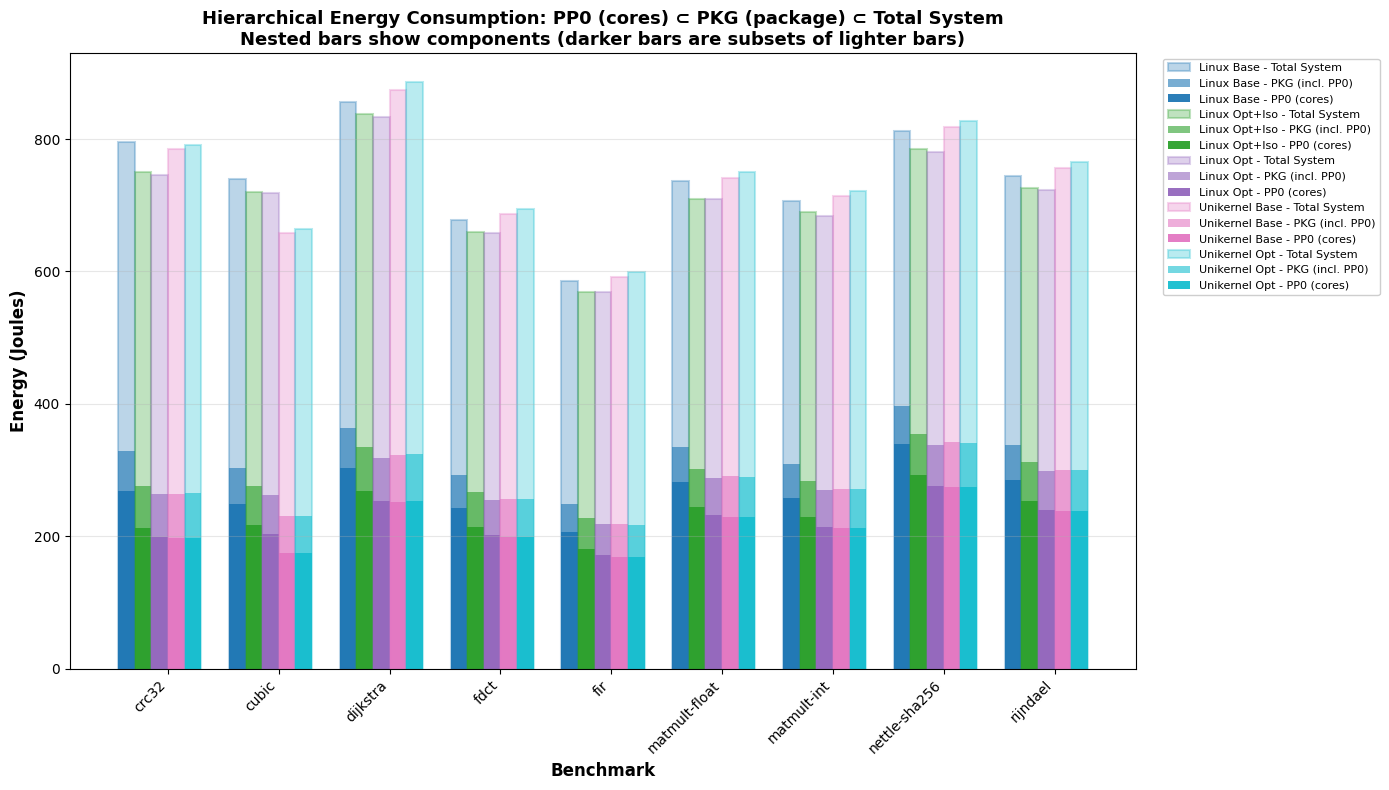

In [45]:
# Create plot showing hierarchical energy consumption: PP0 ⊂ PKG ⊂ Total System Energy
# PP0 (CPU cores) is a subset of PKG (CPU package), which is a subset of total system energy
fig, ax = plt.subplots(figsize=(14, 8))

# Filter out specific configurations and base_linux crc32 only for plotting
plot_df = energy_df[
    (energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on') &
    (energy_df['config'] != 'naive_linux') # &
    # ~((energy_df['config'] == 'base_linux') & (energy_df['benchmark'] == 'crc32'))
] .copy()

# Get unique benchmarks and configs (filter out NaN values)
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define custom order for configs
config_order = [
    'naive_linux',
    'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
# Filter to only configs present in data, maintaining the desired order
configs = [c for c in config_order if c in plot_df['config'].unique()]

# Short names for legend
config_names = {
    'naive_linux': 'Linux Naive',
    'base_linux': 'Linux Base',
    'optimized_linux_iso_eist_c-state_off': 'Linux Opt+Iso',
    'optimized_linux_wo_iso_eist_c-state_off': 'Linux Opt',
    'base_unikernel': 'Unikernel Base',
    'optimized_unikernel': 'Unikernel Opt'
}

# Set up x positions for grouped bars
x = np.arange(len(benchmarks))
width = 0.15  # Width of each bar
colors = plt.cm.tab10(np.linspace(0, 0.9, len(configs)))

# Plot bars for each configuration
for i, config in enumerate(configs):
    config_data = plot_df[plot_df['config'] == config]
    short_name = config_names.get(config, config)
    
    # Prepare data aligned with benchmark order
    pm_energies = []
    pkg_energies = []
    pp0_energies = []
    
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0:
            pm_val = bench_data['powermeter_energy_j'].values[0]
            pkg_val = bench_data['pkg_energy_j'].values[0]
            # Get PP0 data from pc_data
            if config in pc_data:
                pc_bench = pc_data[config][pc_data[config]['benchmark'] == bench]
                pp0_val = pc_bench['pp0_joules'].mean() if len(pc_bench) > 0 else 0
            else:
                pp0_val = 0
            
            # Handle None values
            pm_energies.append(pm_val if pd.notna(pm_val) else 0)
            pkg_energies.append(pkg_val if pd.notna(pkg_val) else 0)
            pp0_energies.append(pp0_val if pd.notna(pp0_val) else 0)
        else:
            pm_energies.append(0)
            pkg_energies.append(0)
            pp0_energies.append(0)
    
    # Plot as nested bars to show hierarchy:
    # - Total system energy (lightest, outermost)
    # - PKG = CPU cores (PP0) + uncore components (middle layer)
    # - PP0 = CPU cores only (darkest, innermost)
    offset = (i - len(configs)/2) * width
    ax.bar(x + offset, pm_energies, width, label=f'{short_name} - Total System', 
           color=colors[i], alpha=0.3, edgecolor=colors[i], linewidth=1.5)
    
    # PKG contains PP0 plus uncore (memory controller, L3 cache, etc.)
    ax.bar(x + offset, pkg_energies, width, label=f'{short_name} - PKG (incl. PP0)', 
           color=colors[i], alpha=0.6)
    
    # PP0 is a component within PKG (CPU cores only)
    ax.bar(x + offset, pp0_energies, width, label=f'{short_name} - PP0 (cores)', 
           color=colors[i], alpha=0.95)

ax.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
ax.set_title('Hierarchical Energy Consumption: PP0 (cores) ⊂ PKG (package) ⊂ Total System\nNested bars show components (darker bars are subsets of lighter bars)', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(benchmarks, rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1, framealpha=0.95)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [46]:
# Calculate coefficient of variation (CV) for energy measurements
# CV = (std / mean) * 100%

cv_results = []

for config_name in subdirs.keys():
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get all PKG energy values for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        pkg_energies = pc_bench['pkg_joules'].values
        
        # Calculate PKG CV
        if len(pkg_energies) > 1:
            pkg_cv = (pkg_energies.std() / pkg_energies.mean()) * 100
        else:
            pkg_cv = None
        
        # Calculate powermeter CV if available
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            powermeter_energies = []
            
            for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                if len(pm_df) < 2:
                    continue
                
                time_span_s = pc_bench.iloc[iteration]['cpu_cycles'] / 3.1e9  # Convert cycles to seconds at 3.1 GHz

                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                energy_j = avg_power_w * time_span_s
                powermeter_energies.append(energy_j)
            
            if len(powermeter_energies) > 1:
                pm_cv = (np.std(powermeter_energies) / np.mean(powermeter_energies)) * 100
            else:
                pm_cv = None
        else:
            pm_cv = None
        
        cv_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pkg_cv': pkg_cv,
            'powermeter_cv': pm_cv
        })

# Convert to DataFrame
cv_df = pd.DataFrame(cv_results)
print(f"CV analysis ready: {len(cv_df)} benchmark-config combinations")

# Print only Linux Naive + crc32 CV row
linux_naive_crc32 = cv_df[
    (cv_df['config'] == 'base_linux') &
    (cv_df['benchmark'] == 'crc32')
]
print(linux_naive_crc32[['config', 'benchmark', 'pkg_cv', 'powermeter_cv' ]])

CV analysis ready: 64 benchmark-config combinations
       config benchmark     pkg_cv  powermeter_cv
0  base_linux     crc32  19.946672      10.502766


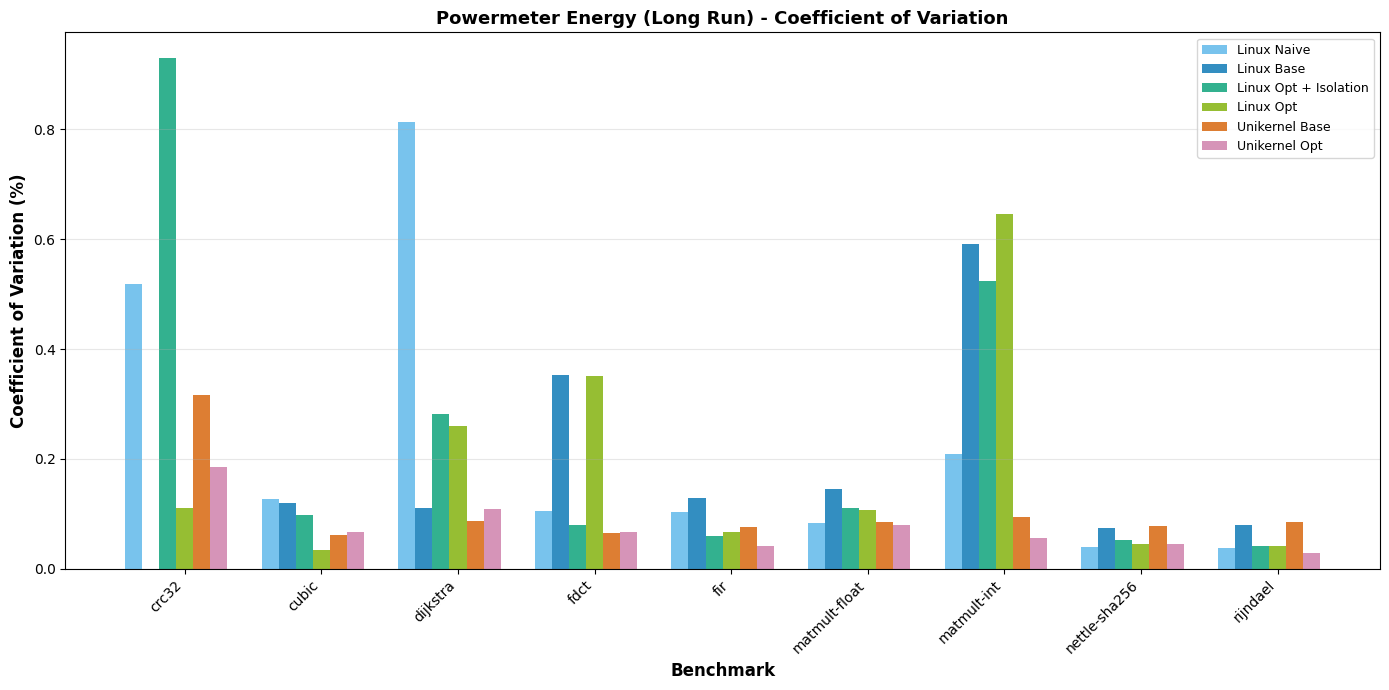

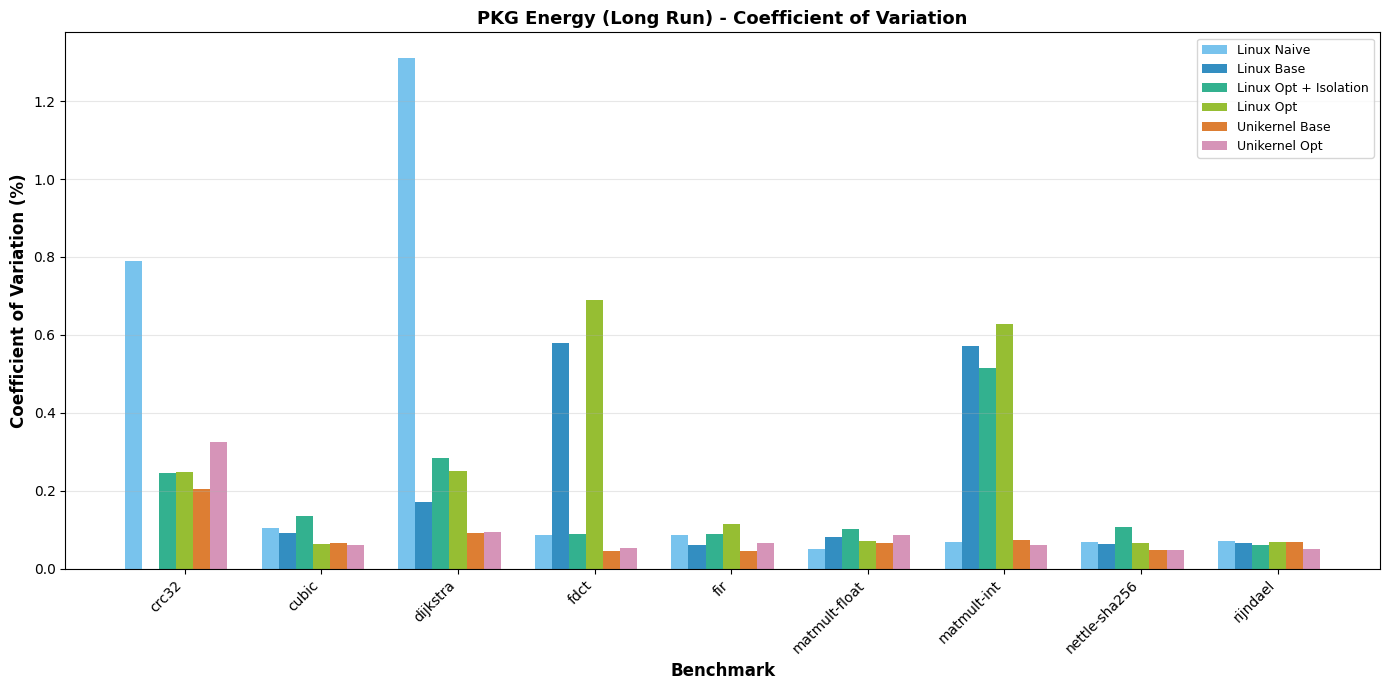

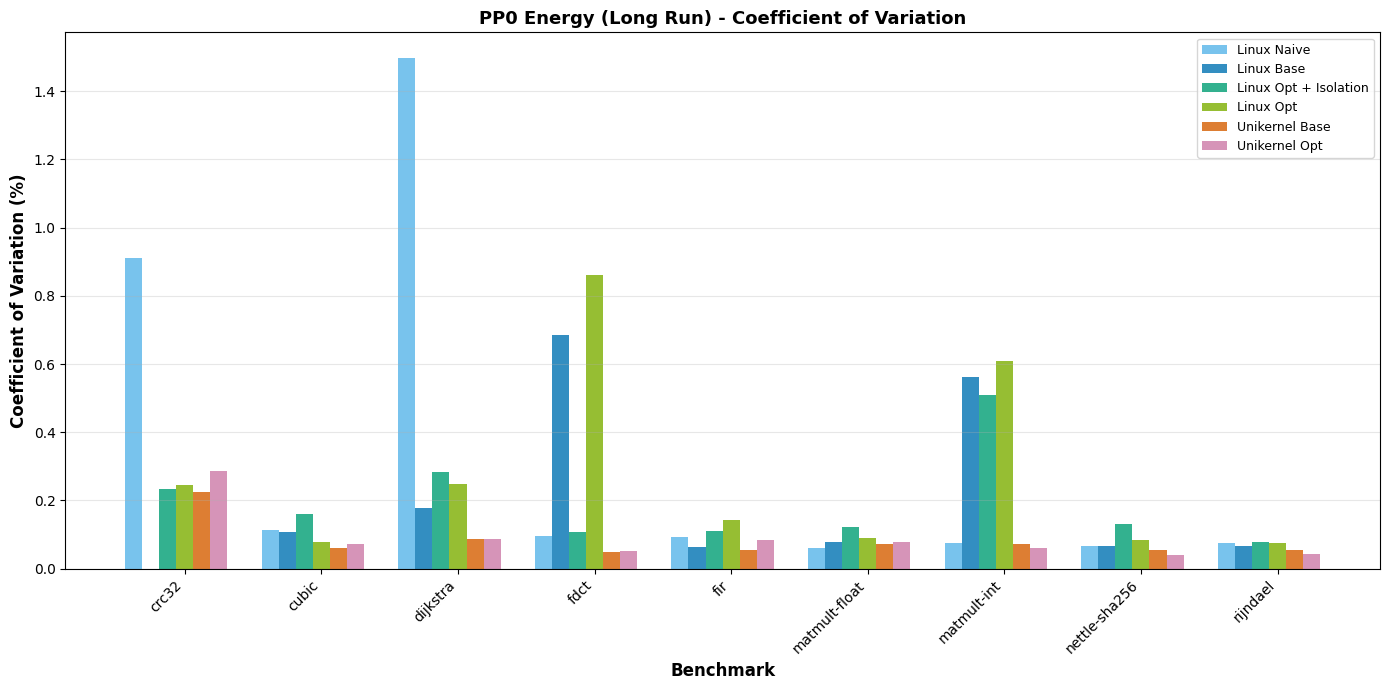

In [58]:
# Create three separate plots for coefficient of variation
# Filter out specific configurations and base_linux crc32 only for plotting
cv_plot_df = cv_df[
    (cv_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on') &
    ~((cv_df['config'] == 'base_linux') & (cv_df['benchmark'] == 'crc32'))
].copy()

# Get unique benchmarks and configs
benchmarks = sorted([b for b in cv_plot_df['benchmark'].unique() if pd.notna(b)])

# Define custom order for configs
config_order = [
    'naive_linux',
    'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in cv_plot_df['config'].unique()]

# Set up x positions
x = np.arange(len(benchmarks)) * 1.2
width = 0.15
config_colors = {
    'naive_linux': '#56B4E9',
    'base_linux': '#0072B2',
    'optimized_linux_iso_eist_c-state_off': '#009E73',
    'optimized_linux_wo_iso_eist_c-state_off': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}

# Plot 1: Powermeter CV
fig1, ax1 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = cv_plot_df[cv_plot_df['config'] == config]
    label = config_labels.get(config, config)
    
    pm_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['powermeter_cv'].values[0]):
            pm_cvs.append(bench_data['powermeter_cv'].values[0])
        else:
            pm_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax1.bar(x + offset, pm_cvs, width, label=label, color=config_colors.get(config, '#7f7f7f'), alpha=0.8)

ax1.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax1.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax1.set_title('Powermeter Energy (Long Run) - Coefficient of Variation', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(benchmarks, rotation=45, ha='right')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: PKG CV
fig2, ax2 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = cv_plot_df[cv_plot_df['config'] == config]
    label = config_labels.get(config, config)
    
    pkg_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['pkg_cv'].values[0]):
            pkg_cvs.append(bench_data['pkg_cv'].values[0])
        else:
            pkg_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax2.bar(x + offset, pkg_cvs, width, label=label, color=config_colors.get(config, '#7f7f7f'), alpha=0.8)

ax2.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax2.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax2.set_title('PKG Energy (Long Run) - Coefficient of Variation', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(benchmarks, rotation=45, ha='right')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: PP0 CV
# Calculate PP0 CV results
pp0_cv_results = []

for config_name in subdirs.keys():
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get all PP0 energy values for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        pp0_energies = pc_bench['pp0_joules'].values
        
        # Calculate PP0 CV
        if len(pp0_energies) > 1:
            pp0_cv = (pp0_energies.std() / pp0_energies.mean()) * 100
        else:
            pp0_cv = None
        
        pp0_cv_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pp0_cv': pp0_cv
        })

# Convert to DataFrame
pp0_cv_df = pd.DataFrame(pp0_cv_results)

# Filter out specific configurations and base_linux crc32 only for plotting
pp0_cv_plot_df = pp0_cv_df[
    (pp0_cv_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on') &
    ~((pp0_cv_df['config'] == 'base_linux') & (pp0_cv_df['benchmark'] == 'crc32'))
].copy()

fig3, ax3 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = pp0_cv_plot_df[pp0_cv_plot_df['config'] == config]
    label = config_labels.get(config, config)
    
    pp0_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['pp0_cv'].values[0]):
            pp0_cvs.append(bench_data['pp0_cv'].values[0])
        else:
            pp0_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax3.bar(x + offset, pp0_cvs, width, label=label, color=config_colors.get(config, '#7f7f7f'), alpha=0.8)

ax3.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax3.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax3.set_title('PP0 Energy (Long Run) - Coefficient of Variation', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(benchmarks, rotation=45, ha='right')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1589297861.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


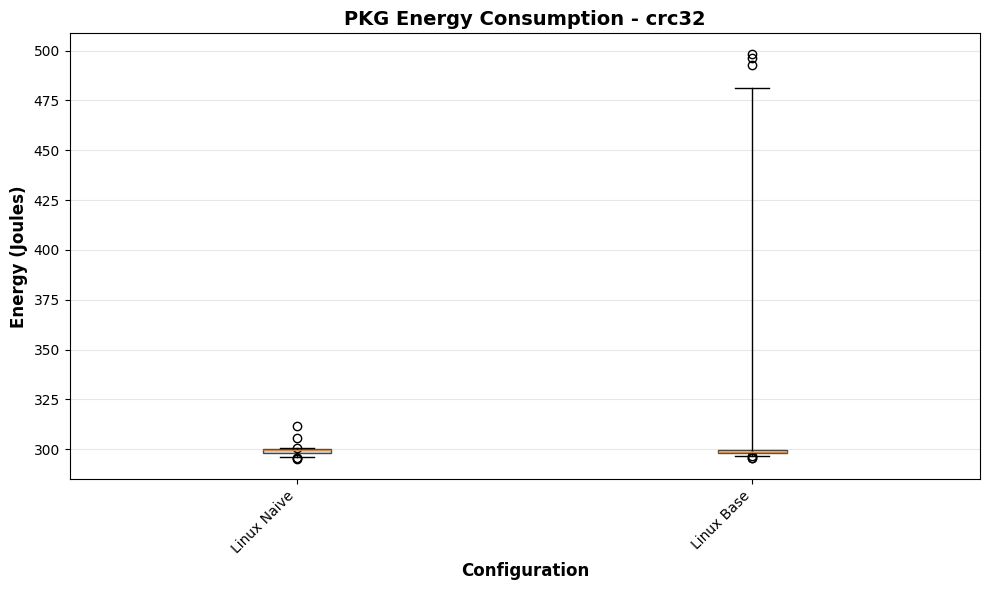

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1589297861.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


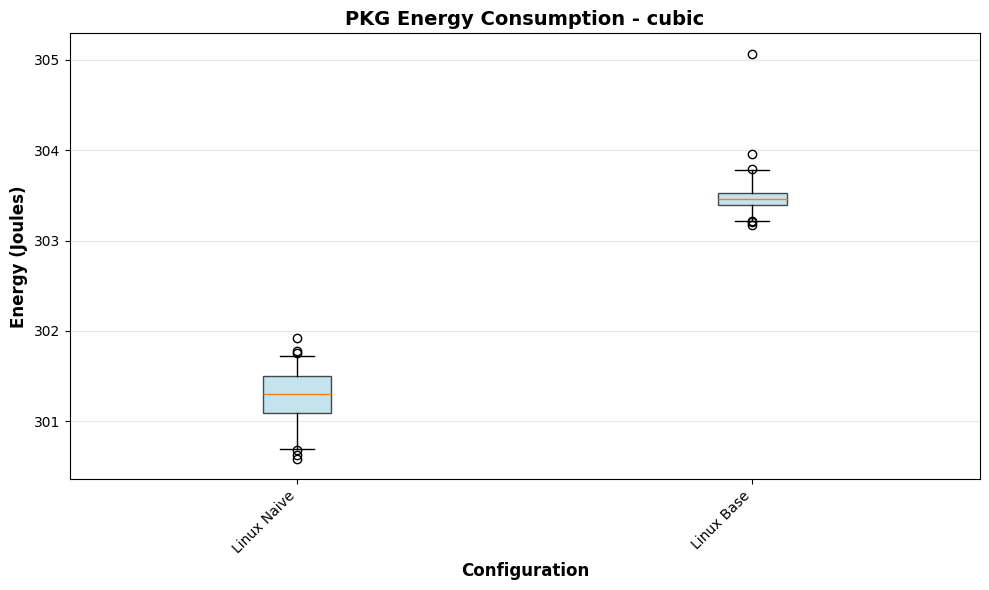

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1589297861.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


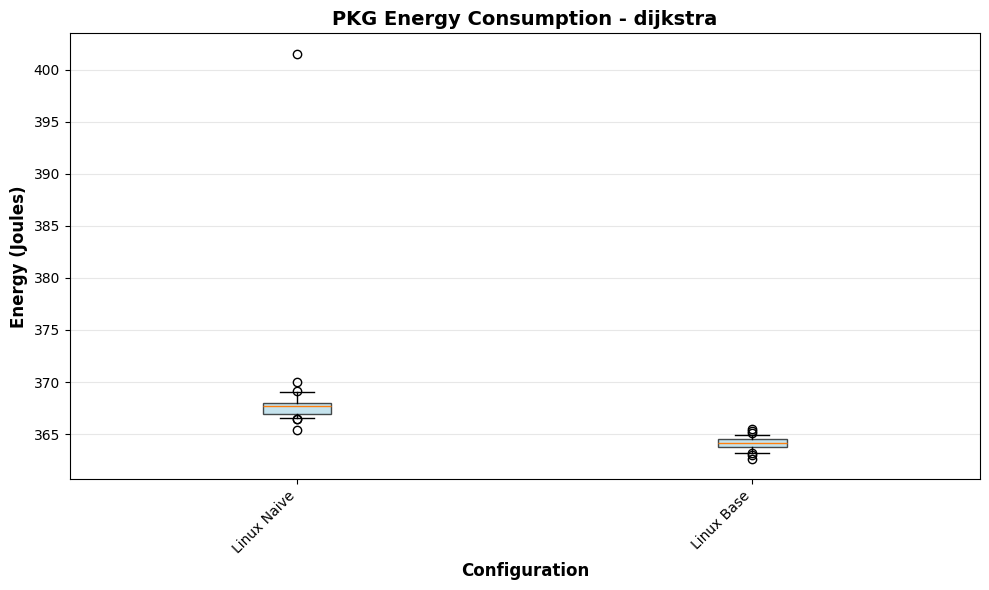

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1589297861.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


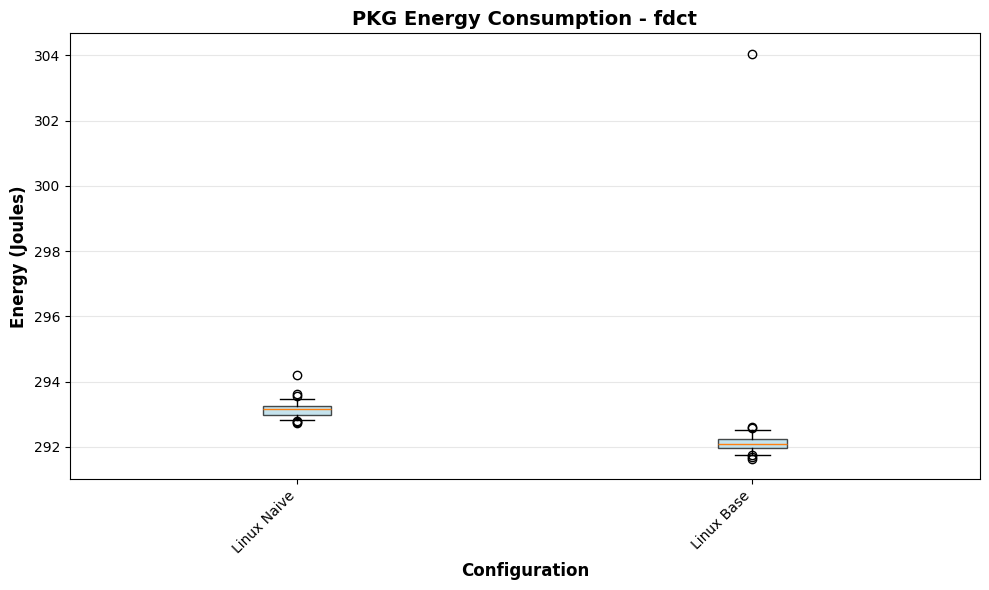

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1589297861.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


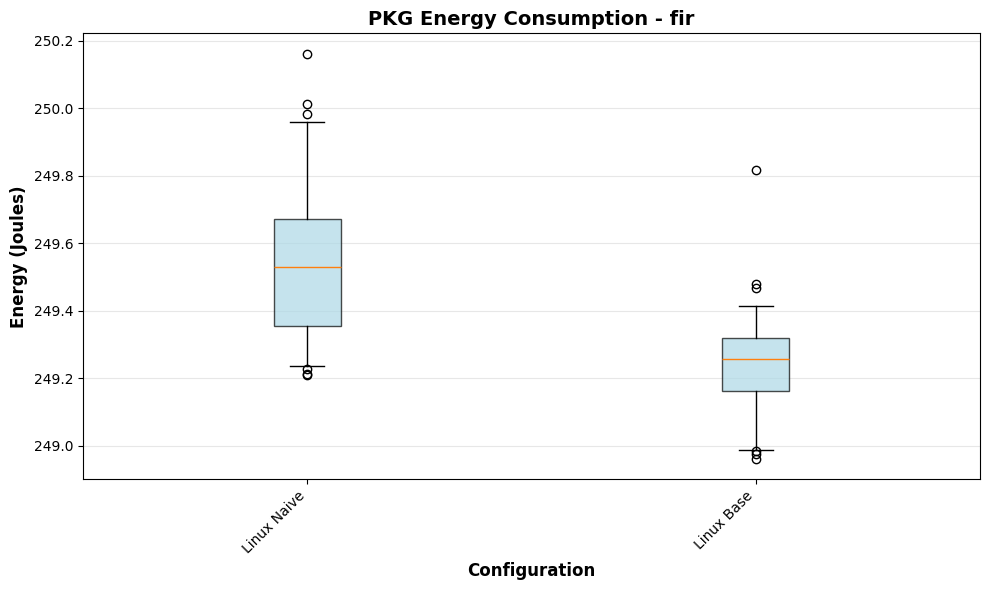

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1589297861.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


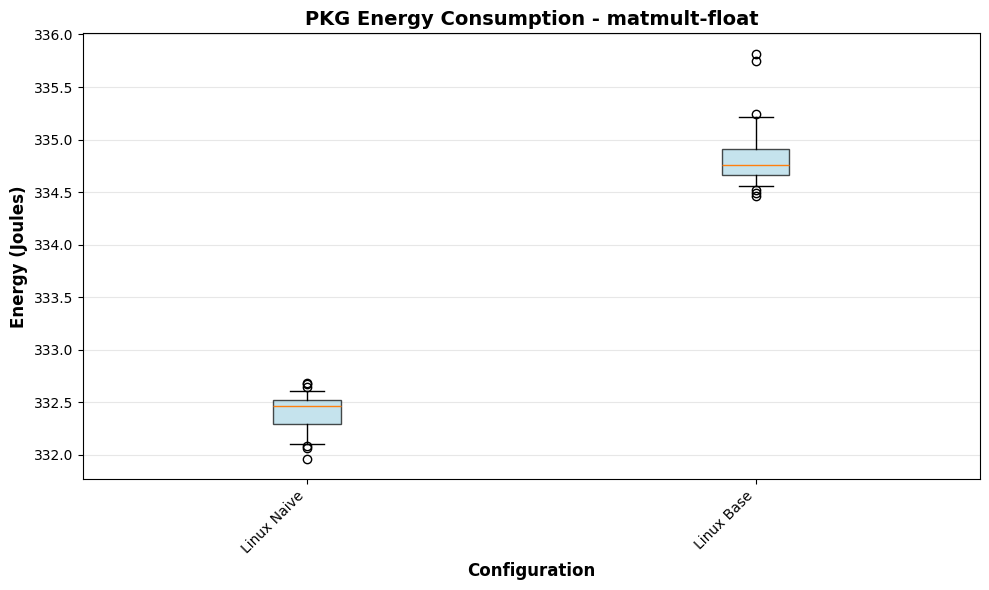

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1589297861.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


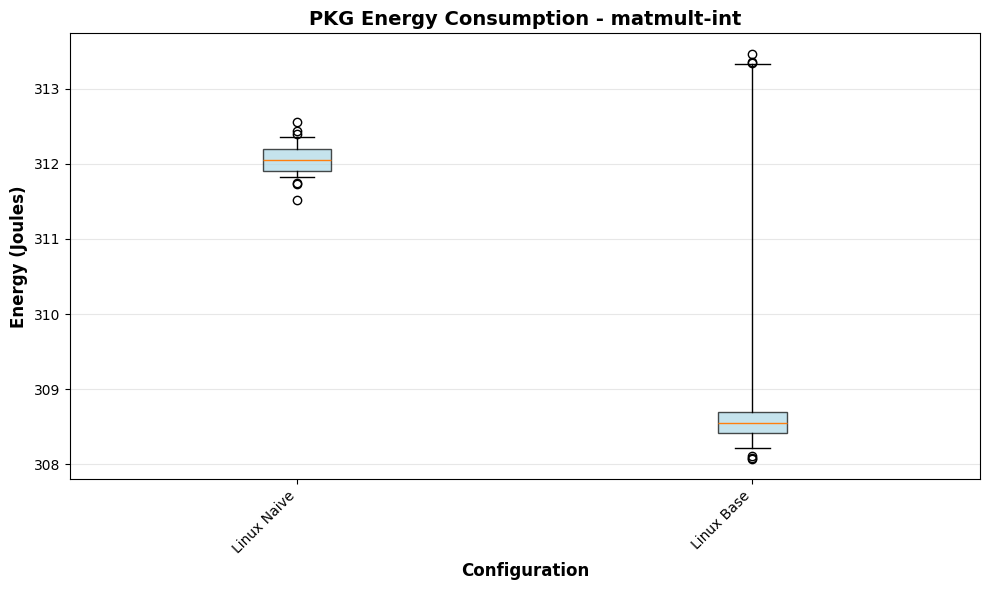

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1589297861.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


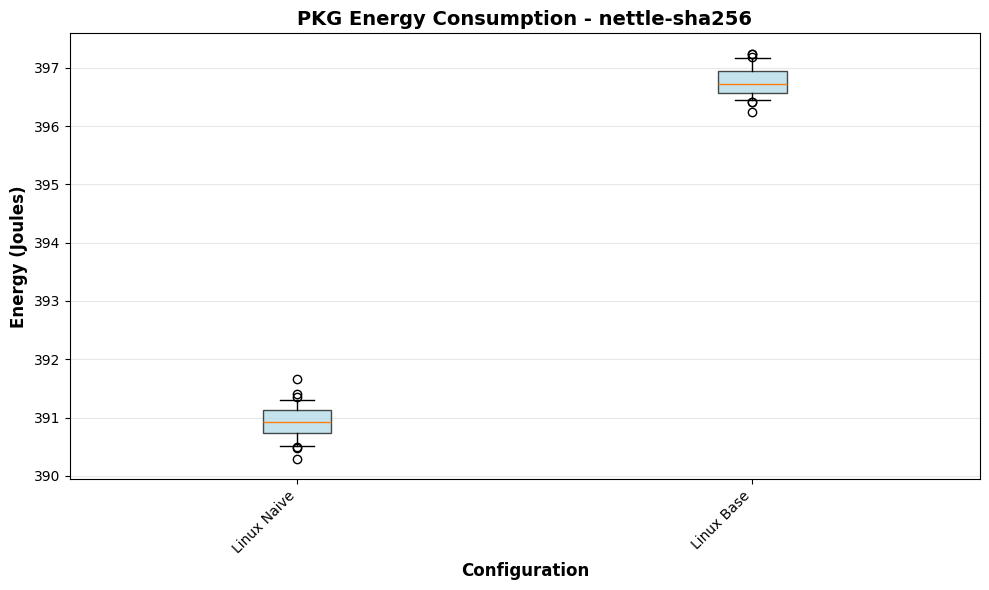

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1589297861.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


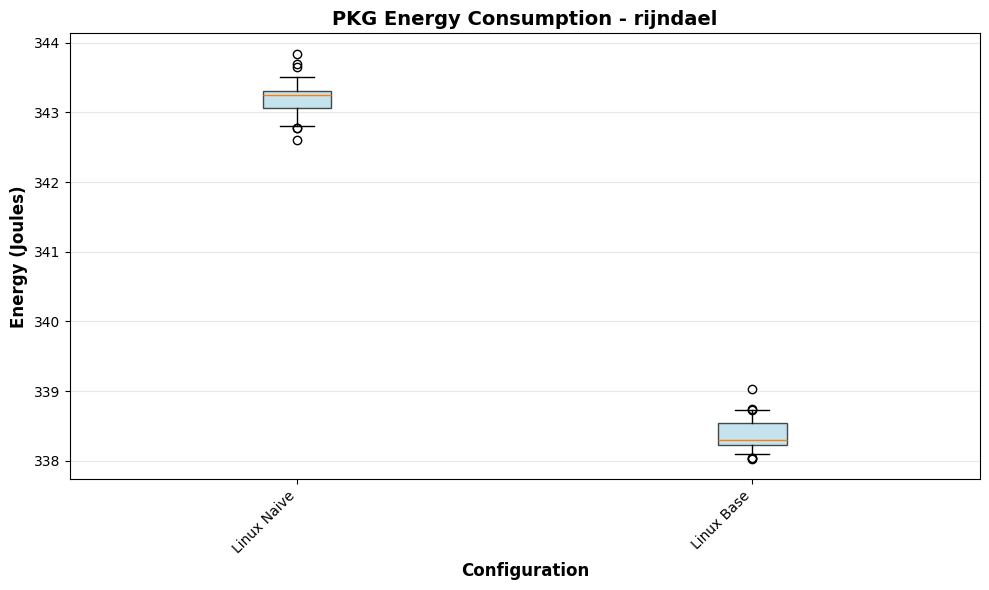

In [59]:
# Boxplot for PKG energy consumption per benchmark
# One plot per benchmark, showing all configurations

plot_df = energy_df[
    (energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on') &
    ~((energy_df['config'] == 'base_linux') & (energy_df['benchmark'] == 'crc32'))
] .copy()

# Get unique benchmarks
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    'naive_linux',
    'base_linux',
    # 'optimized_linux_iso_eist_c-state_off',
    # 'optimized_linux_wo_iso_eist_c-state_off',
    # 'base_unikernel',
    # 'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys() and c != 'optimized_linux_wo_iso_eist_c-state_on']

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            data_to_plot.append(pc_bench['pkg_joules'].values)
            labels.append(config_labels.get(config_name, config_name))
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))
        
        # Customize boxplot appearance
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'PKG Energy Consumption - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/510472805.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


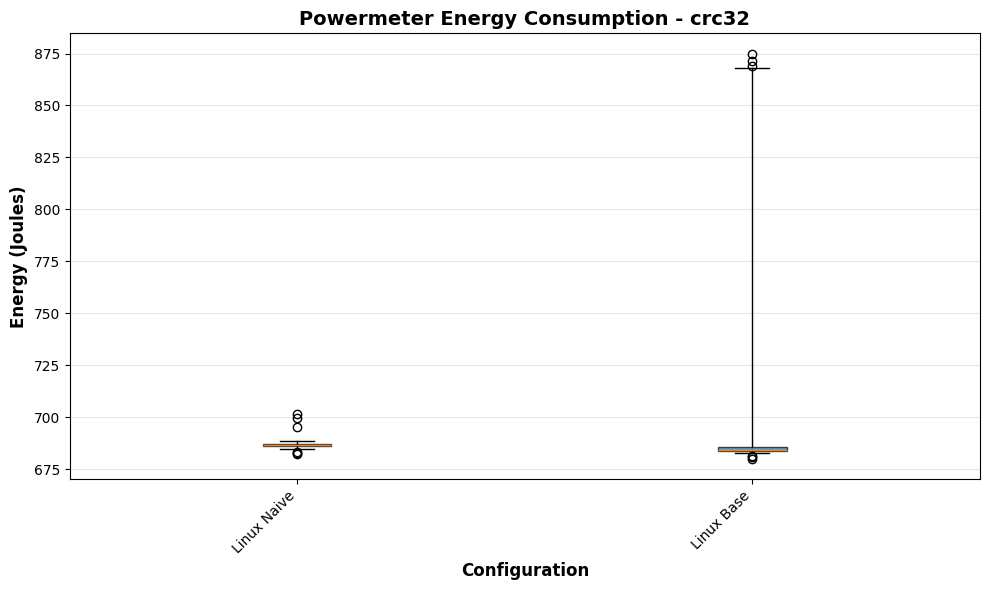

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/510472805.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


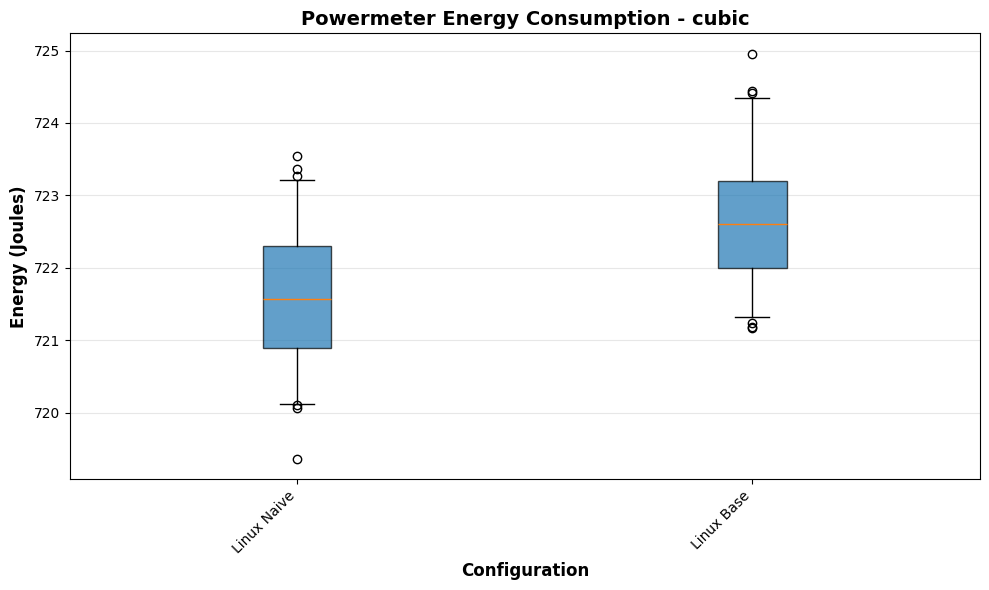

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/510472805.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


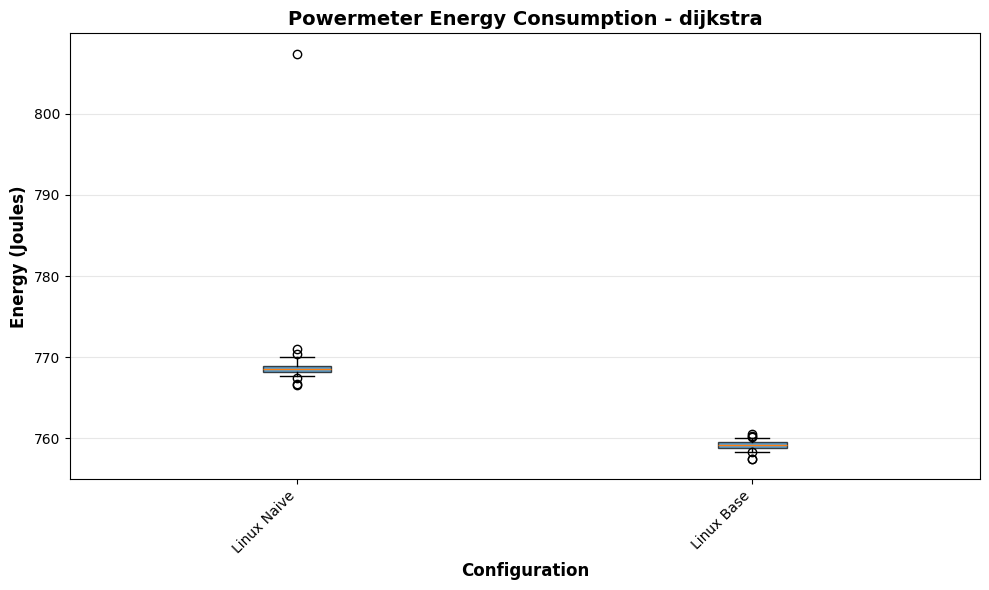

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/510472805.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


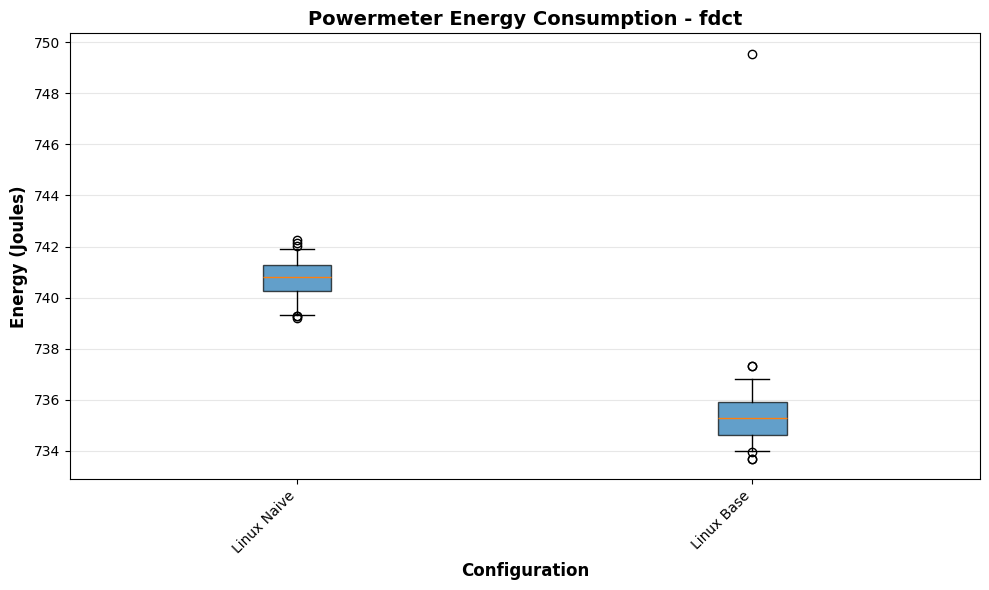

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/510472805.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


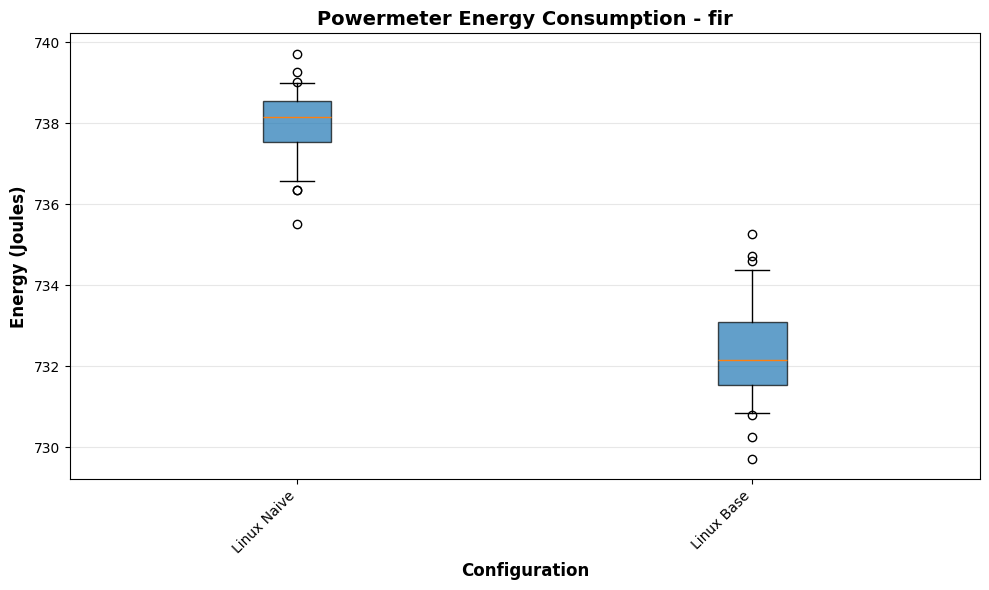

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/510472805.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


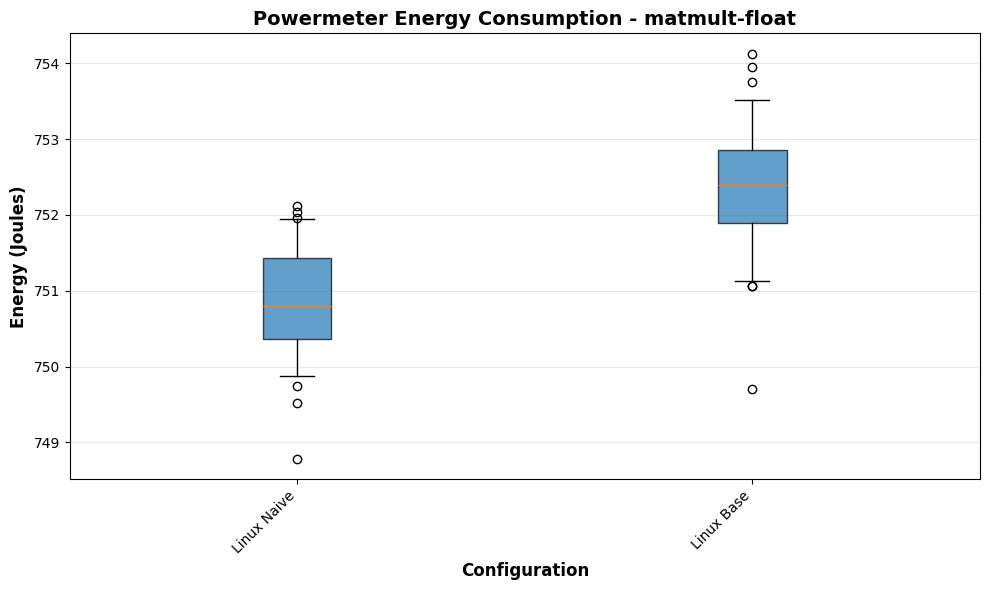

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/510472805.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


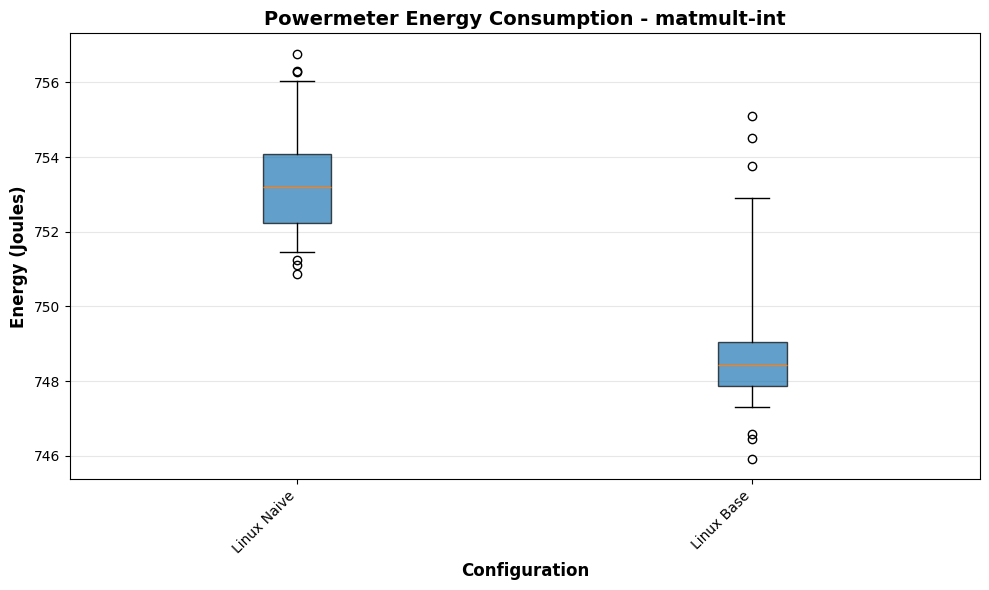

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/510472805.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


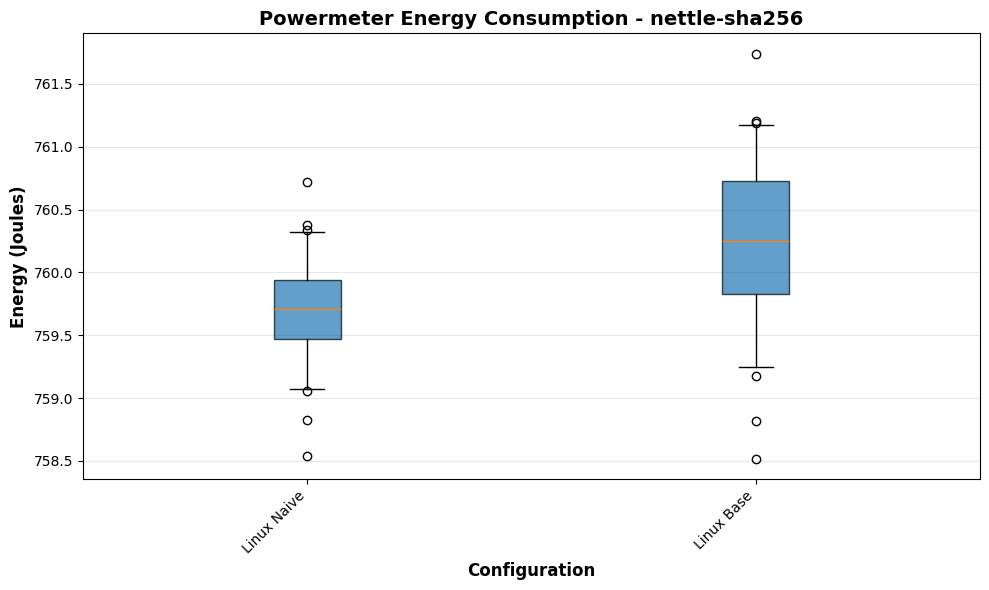

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/510472805.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


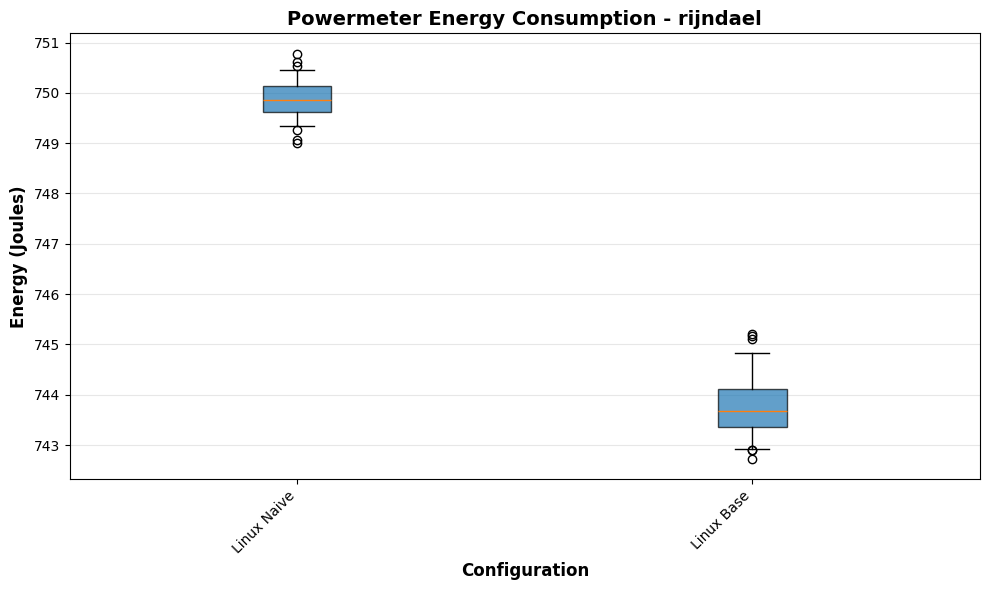

In [60]:
# Boxplot for powermeter energy consumption per benchmark
# One plot per benchmark, showing all configurations

plot_df = energy_df[
    (energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on') &
    ~((energy_df['config'] == 'base_linux') & (energy_df['benchmark'] == 'crc32'))
] .copy()

# Get unique benchmarks
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    'naive_linux',
    'base_linux',
    # 'optimized_linux_iso_eist_c-state_off',
    # 'optimized_linux_wo_iso_eist_c-state_off',
    # 'base_unikernel',
    # 'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys() ]
#configs = [c for c in config_order if c in subdirs.keys() and c != 'optimized_linux_wo_iso_eist_c-state_on']

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    
    for config_name in configs:
        bench_data = []
        
        # Get powermeter data for this config and benchmark
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                if len(pm_df) < 2:
                    continue
                
                time_span_s = pc_bench.iloc[iteration]['cpu_cycles'] / 3.1e9  # Convert cycles to seconds at 3.1 GHz
                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                energy_j = avg_power_w * time_span_s
                bench_data.append(energy_j)
        
        if bench_data:
            data_to_plot.append(bench_data)
            labels.append(config_labels.get(config_name, config_name))
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))
        
        # Customize boxplot appearance
        for patch in bp['boxes']:
            # patch.set_facecolor('lightcoral')
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'Powermeter Energy Consumption - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/270085355.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


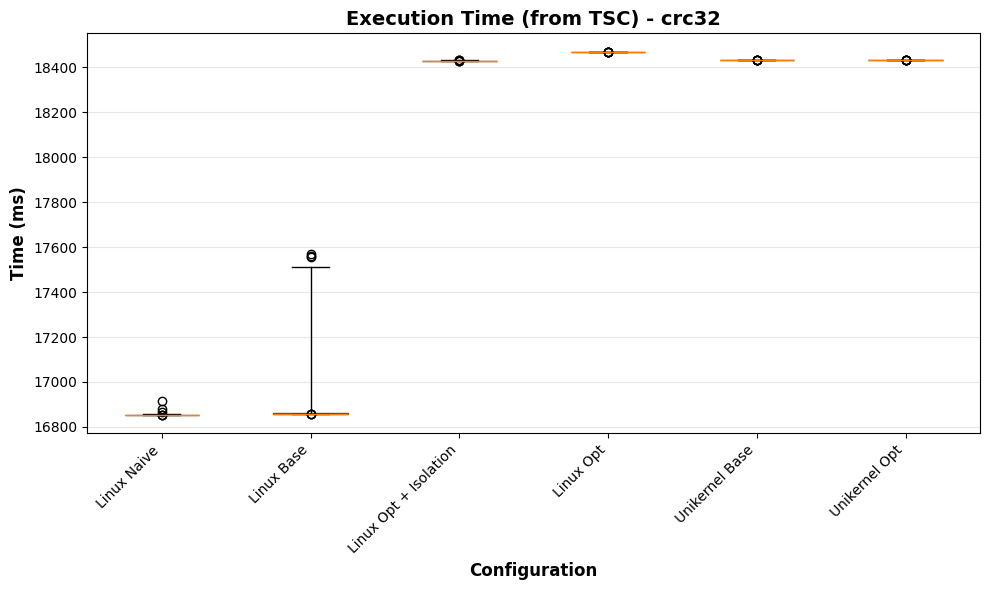

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/270085355.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


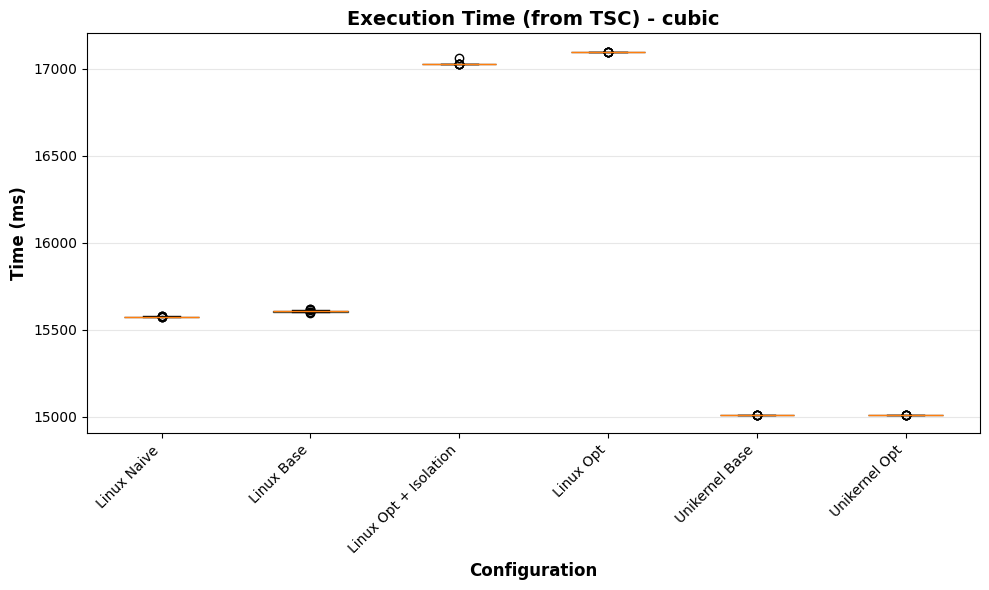

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/270085355.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


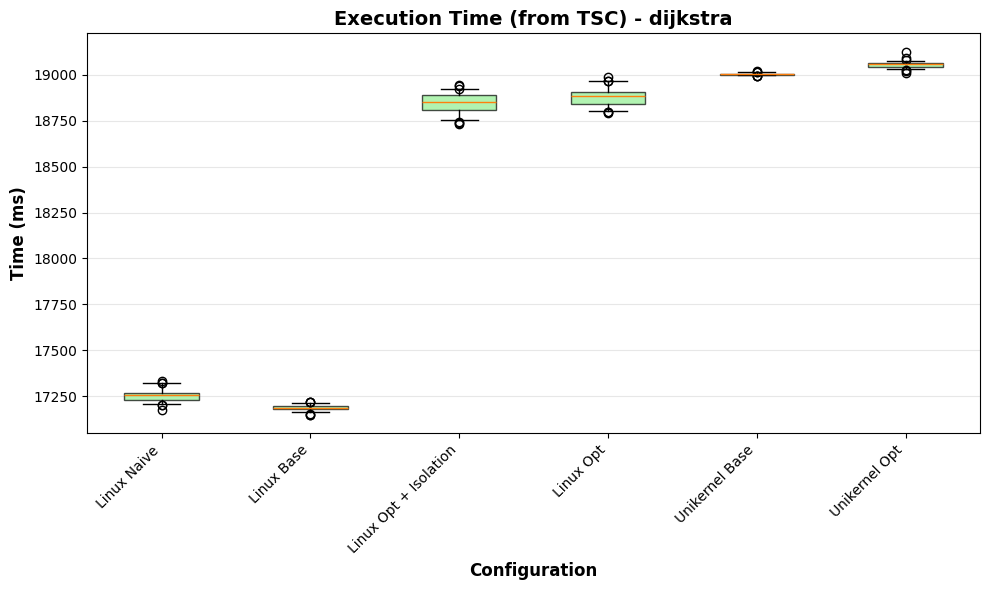

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/270085355.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


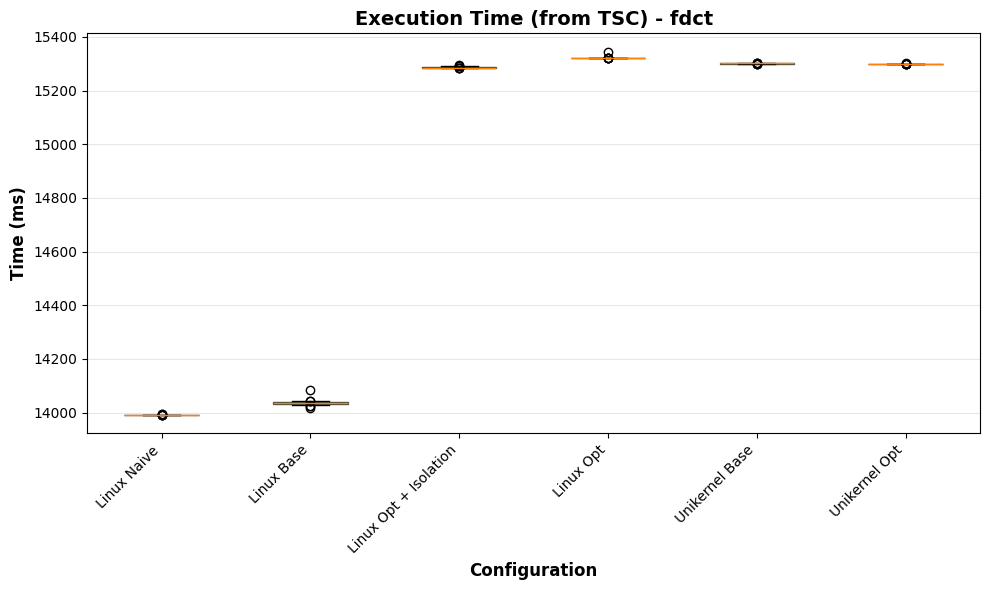

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/270085355.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


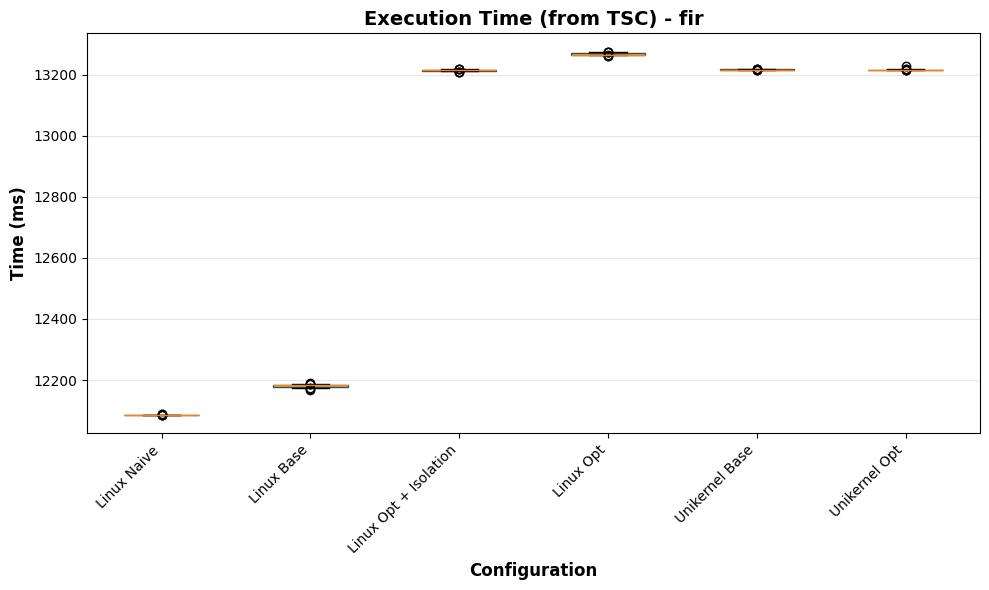

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/270085355.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


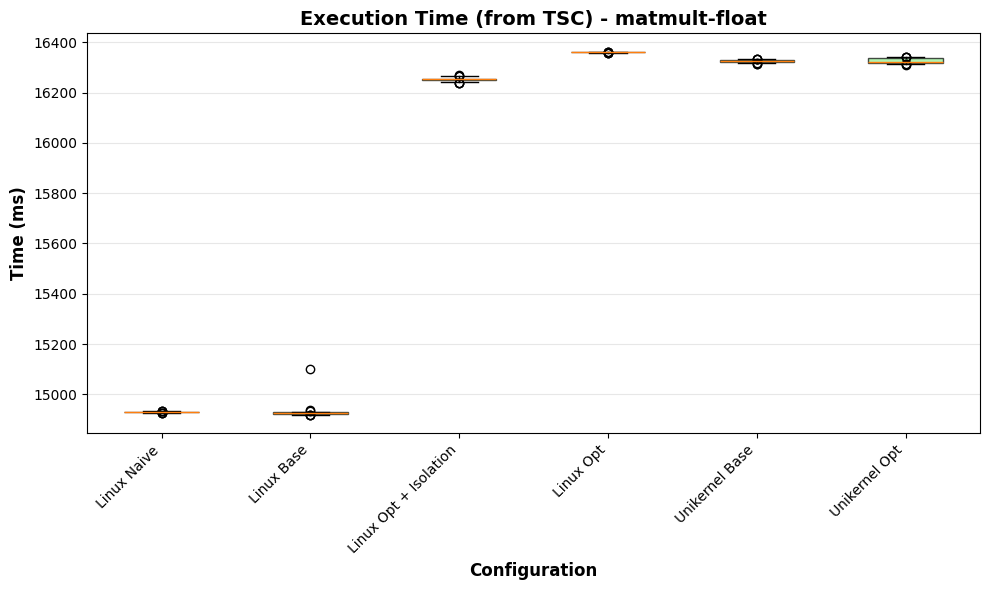

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/270085355.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


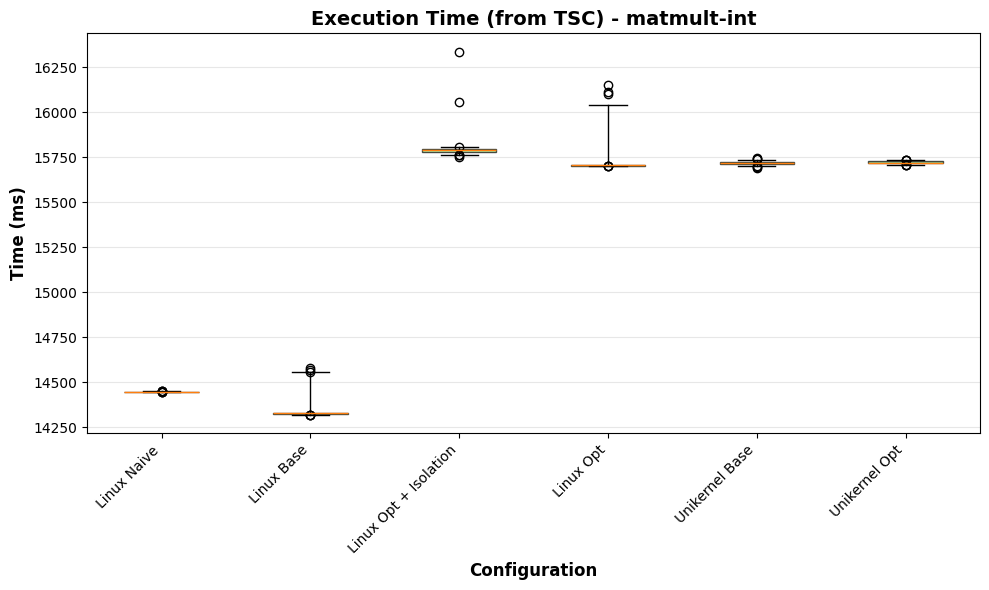

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/270085355.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


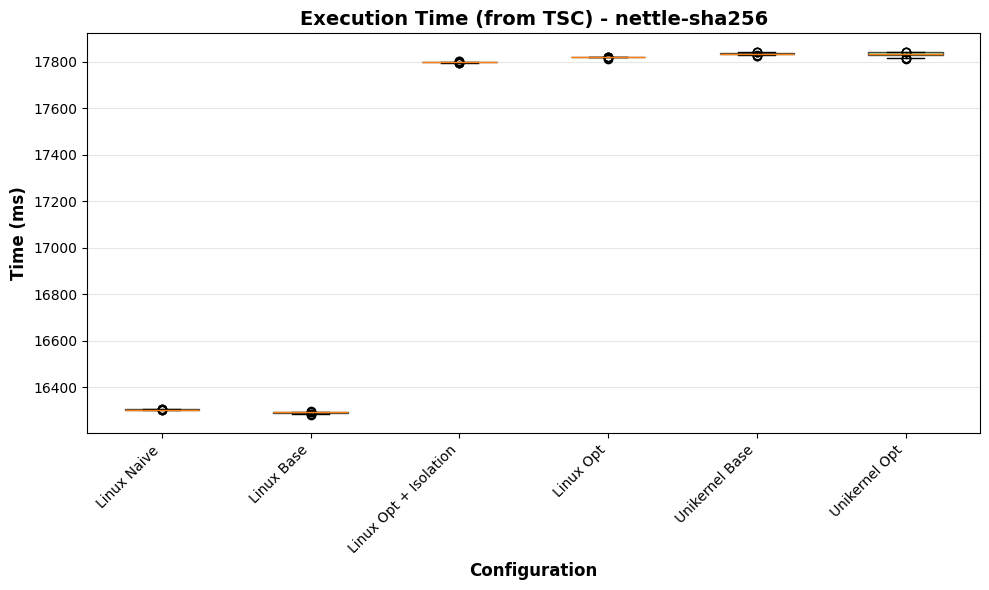

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/270085355.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


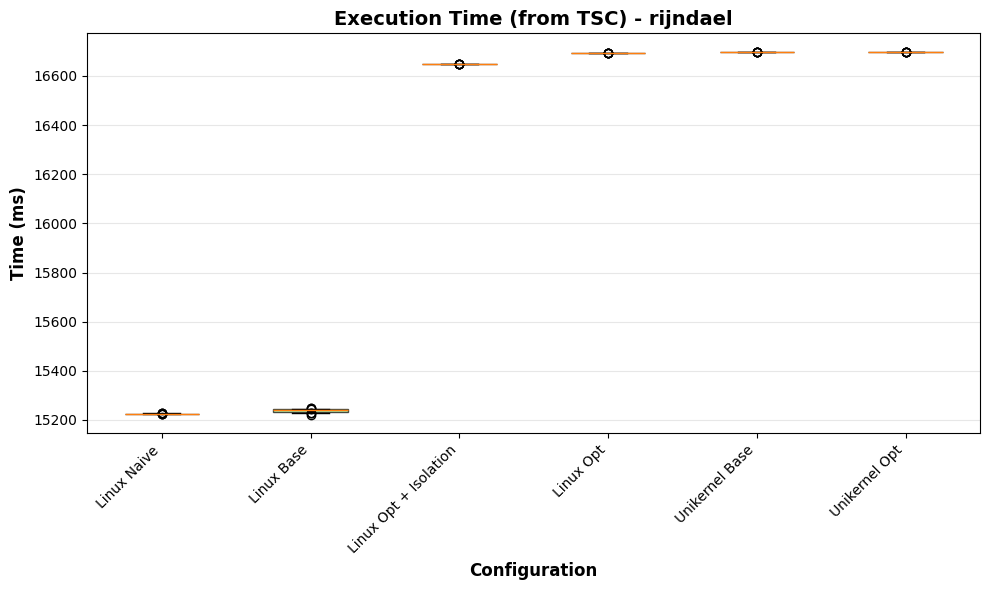


Coefficient of Variation (CV) for Execution Time


Configuration  Linux Naive  Linux Base  Linux Opt + Isolation  Linux Opt  Unikernel Base  Unikernel Opt
Benchmark                                                                                              
crc32             0.055330    1.360554               0.000395   0.000403        0.000520       0.000352
cubic             0.004780    0.030171               0.026713   0.000432        0.001609       0.001068
dijkstra          0.190995    0.098033               0.295886   0.256603        0.029355       0.097199
fdct              0.007652    0.061561               0.012496   0.021282        0.003085       0.002173
fir               0.006740    0.038948               0.017593   0.032391        0.007480       0.014315
matmult-float     0.011343    0.164886               0.044291   0.008224        0.032417       0.065951
matmult-int       0.006880    0.592393               0.545271   0.690477        0.068460       0.052152
nettle-sha25

In [61]:
# Boxplot for execution time per benchmark
# One plot per benchmark, showing all configurations

plot_df = energy_df[
    (energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on') &
    ~((energy_df['config'] == 'base_linux') & (energy_df['benchmark'] == 'crc32'))
] .copy()

# Get unique benchmarks
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    'naive_linux',
    'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys() and c != 'optimized_linux_wo_iso_eist_c-state_on']

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            # Calculate time in ms from cpu_cycles using base frequency of 3.1 GHz
            # time (ms) = cycles / (3.1 × 10^9 Hz) × 1000 = cycles / 3.1e6
            time_ms = pc_bench['cpu_cycles'].values / 3.1e6
            data_to_plot.append(time_ms)
            labels.append(config_labels.get(config_name, config_name))
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))
        
        # Customize boxplot appearance
        for patch in bp['boxes']:
            patch.set_facecolor('lightgreen')
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Time (ms)', fontsize=12, fontweight='bold')
        ax.set_title(f'Execution Time (from TSC) - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Calculate and display CV table for execution time
print("\n" + "="*80)
print("Coefficient of Variation (CV) for Execution Time")
print("="*80)

time_cv_results = []

for config_name in configs:
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    
    for benchmark in benchmarks:
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 1:
            # Calculate time in ms from cpu_cycles
            time_ms = pc_bench['cpu_cycles'].values / 3.1e6
            time_cv = (time_ms.std() / time_ms.mean()) * 100
        else:
            time_cv = None
        
        time_cv_results.append({
            'Configuration': config_labels.get(config_name, config_name),
            'Benchmark': benchmark,
            'CV (%)': time_cv
        })

# Convert to DataFrame and pivot for better display
time_cv_df = pd.DataFrame(time_cv_results)
time_cv_pivot = time_cv_df.pivot(index='Benchmark', columns='Configuration', values='CV (%)')

# Reorder columns to match config_order
time_cv_pivot = time_cv_pivot[[config_labels.get(c, c) for c in configs if config_labels.get(c, c) in time_cv_pivot.columns]]

print("\n")
print(time_cv_pivot.to_string())
print("\n" + "="*80)

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1450434475.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


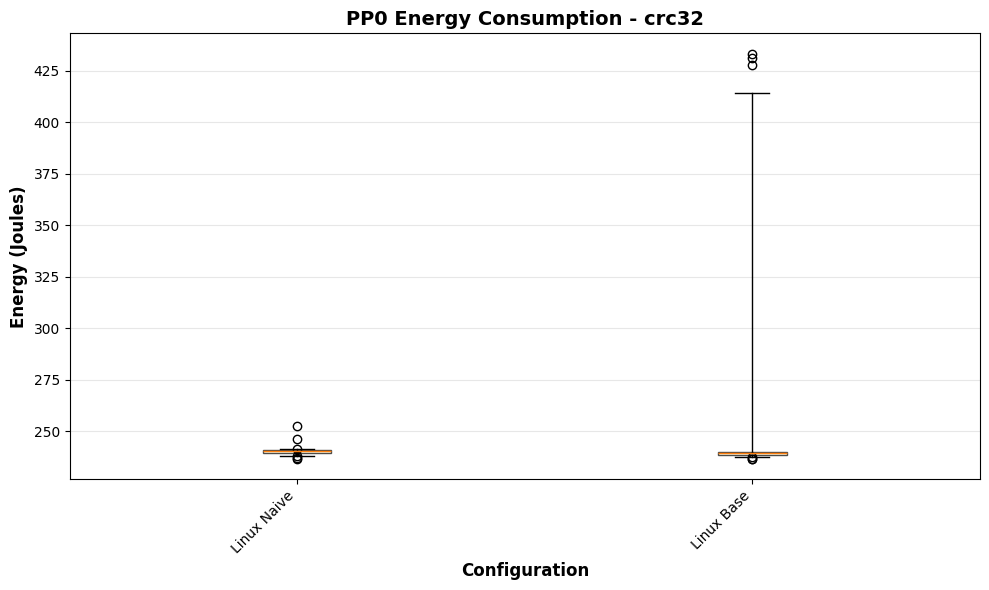

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1450434475.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


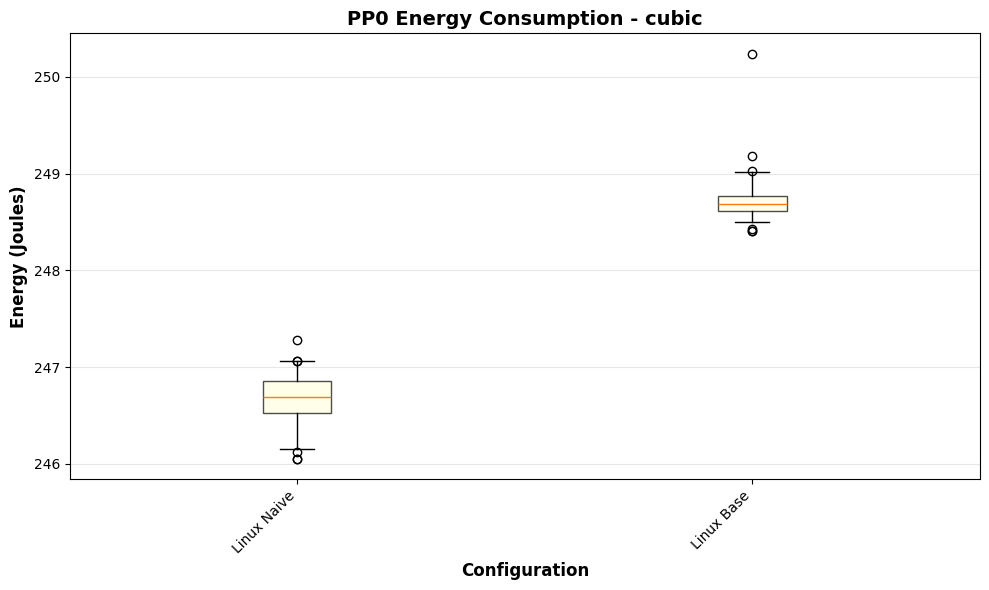

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1450434475.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


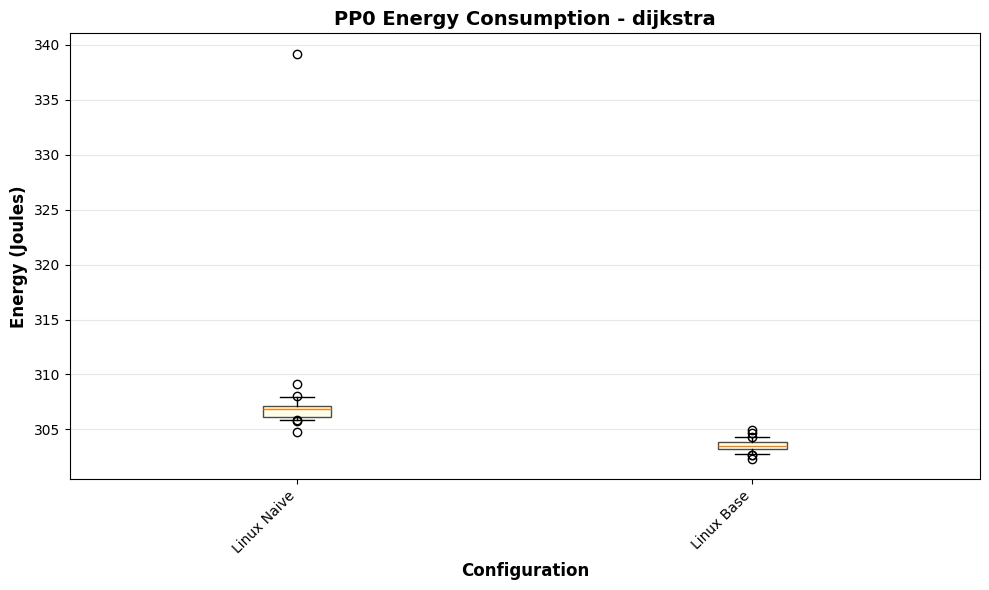

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1450434475.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


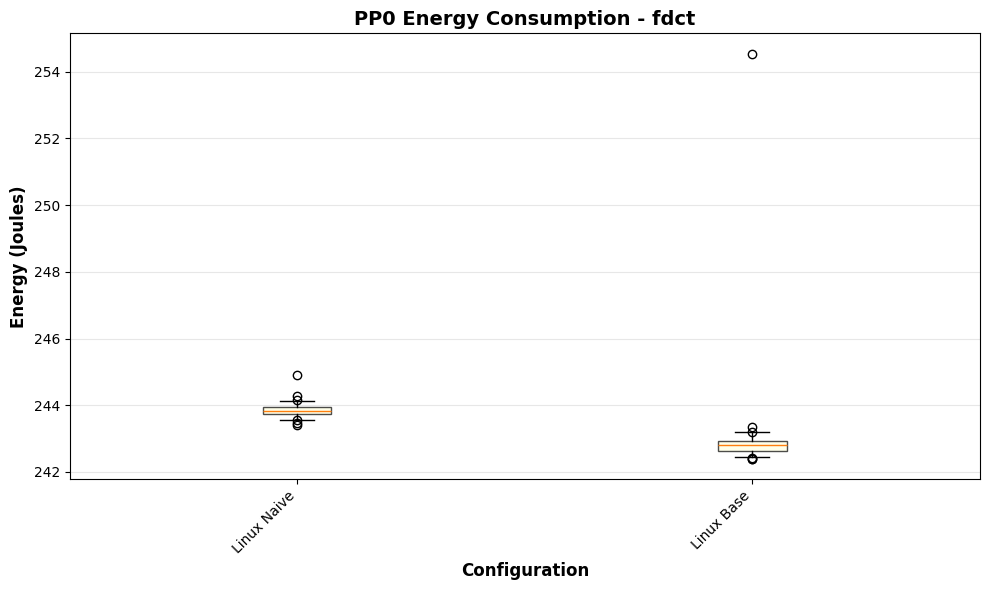

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1450434475.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


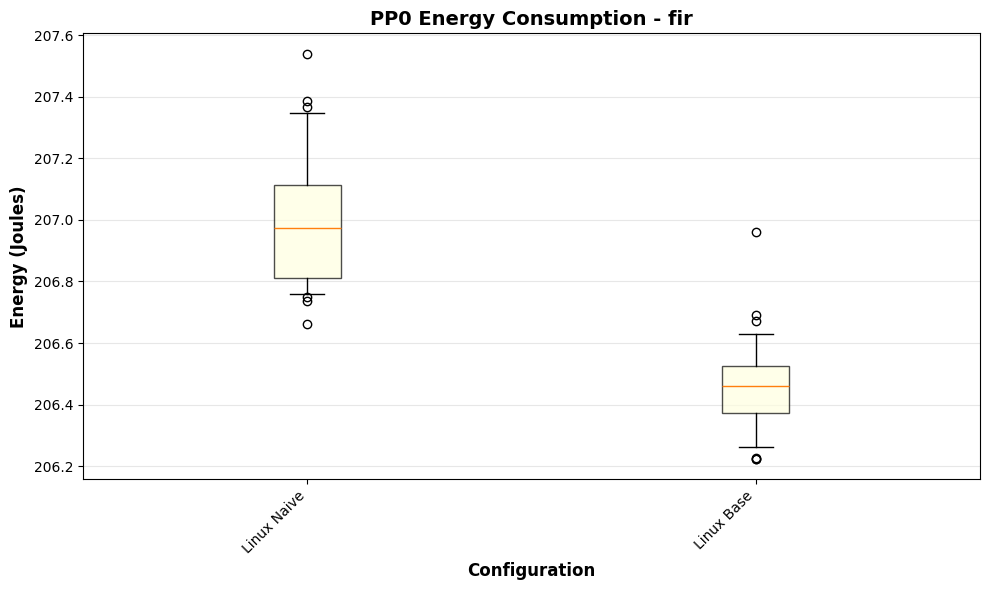

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1450434475.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


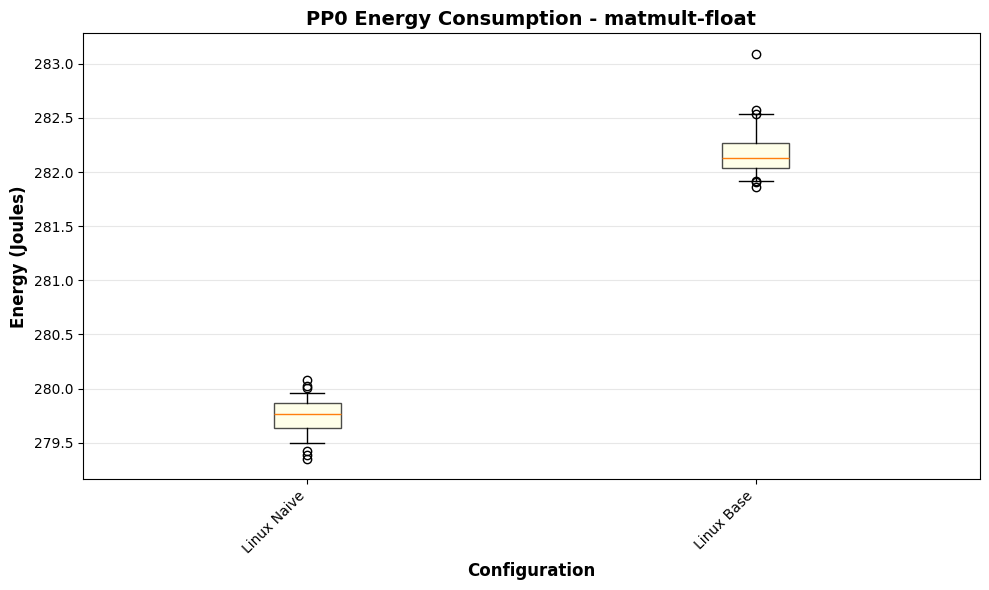

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1450434475.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


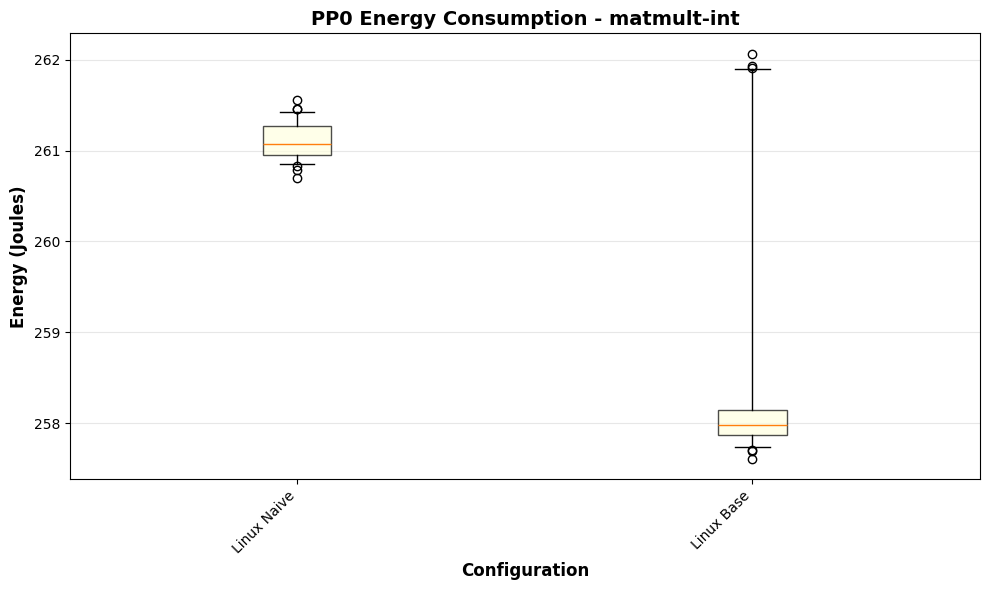

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1450434475.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


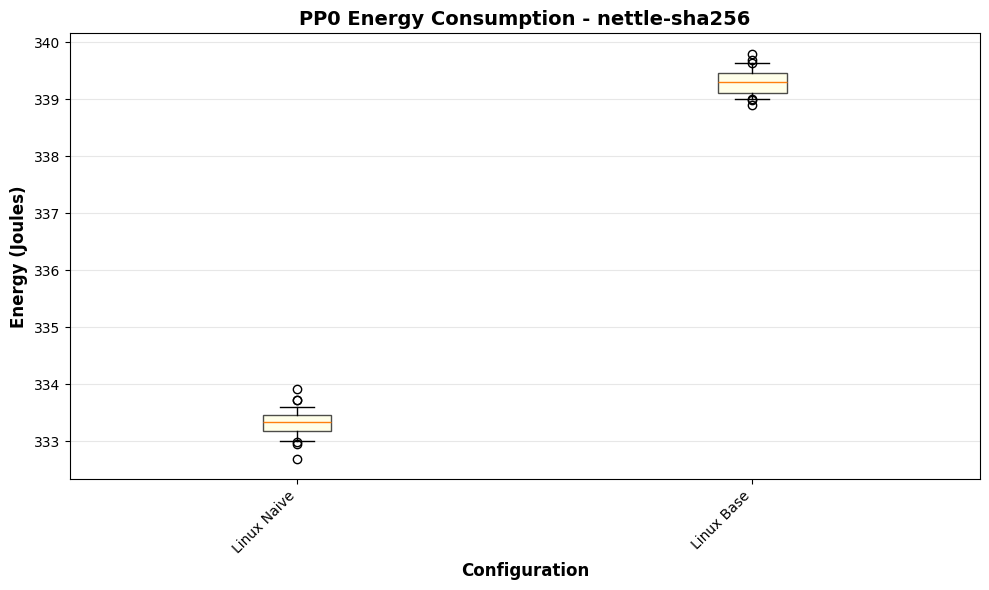

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_52837/1450434475.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


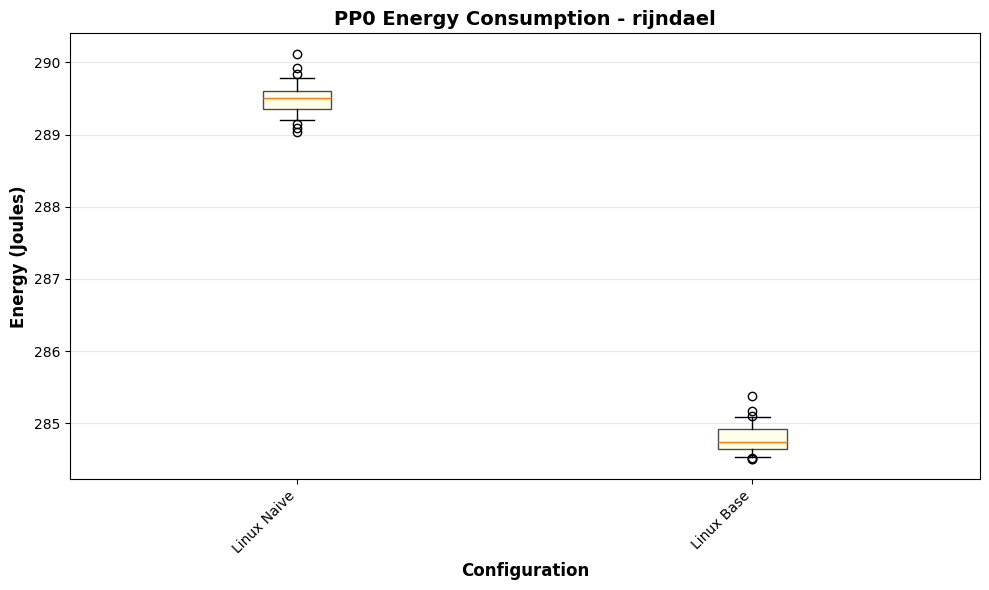


Coefficient of Variation (CV) for PP0 Energy


Configuration  Linux Naive  Linux Base
Benchmark                             
crc32             0.910803   23.600135
cubic             0.112000    0.108313
dijkstra          1.497583    0.176515
fdct              0.096849    0.683750
fir               0.092650    0.064750
matmult-float     0.059934    0.077744
matmult-int       0.075603    0.561028
nettle-sha256     0.067821    0.066599
rijndael          0.074730    0.067848



In [62]:
# Boxplot for PP0 energy consumption per benchmark with CV table
# One plot per benchmark, showing all configurations

plot_df = energy_df[
    (energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on') &
    ~((energy_df['config'] == 'base_linux') & (energy_df['benchmark'] == 'crc32'))
] .copy()

# Get unique benchmarks
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    'naive_linux',
    'base_linux',
    # 'optimized_linux_iso_eist_c-state_off',
    # 'optimized_linux_wo_iso_eist_c-state_off',
    # 'base_unikernel',
    # 'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys() and c != 'optimized_linux_wo_iso_eist_c-state_on']

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            data_to_plot.append(pc_bench['pp0_joules'].values)
            labels.append(config_labels.get(config_name, config_name))
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))
        
        # Customize boxplot appearance
        for patch in bp['boxes']:
            patch.set_facecolor('lightyellow')
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'PP0 Energy Consumption - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Calculate and display CV table for PP0 energy
print("\n" + "="*80)
print("Coefficient of Variation (CV) for PP0 Energy")
print("="*80)

pp0_energy_cv_results = []

for config_name in configs:
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    
    for benchmark in benchmarks:
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 1:
            # Calculate PP0 energy CV
            pp0_energy = pc_bench['pp0_joules'].values
            pp0_energy_cv = (pp0_energy.std() / pp0_energy.mean()) * 100
        else:
            pp0_energy_cv = None
        
        pp0_energy_cv_results.append({
            'Configuration': config_labels.get(config_name, config_name),
            'Benchmark': benchmark,
            'CV (%)': pp0_energy_cv
        })

# Convert to DataFrame and pivot for better display
pp0_energy_cv_df = pd.DataFrame(pp0_energy_cv_results)
pp0_energy_cv_pivot = pp0_energy_cv_df.pivot(index='Benchmark', columns='Configuration', values='CV (%)')

# Reorder columns to match config_order
pp0_energy_cv_pivot = pp0_energy_cv_pivot[[config_labels.get(c, c) for c in configs if config_labels.get(c, c) in pp0_energy_cv_pivot.columns]]

print("\n")
print(pp0_energy_cv_pivot.to_string())
print("\n" + "="*80)


In [63]:
# Calculate total execution time for each configuration
print("Total execution time per configuration:")
print("=" * 60)

for config_name in subdirs.keys():
    # Skip naive_linux
    if config_name == 'naive_linux':
        continue
        
    if config_name not in pc_data:
        print(f"{config_labels.get(config_name, config_name)}: No data available")
        continue
    
    pc_df = pc_data[config_name]
    display_name = config_labels.get(config_name, config_name)
    
    # Sum all execution times
    total_time_ms = pc_df['cooldown_ms'].sum()
    total_time_s = total_time_ms / 1000
    total_time_min = total_time_s / 60
    
    # Count number of measurements
    num_measurements = len(pc_df)
    
    print(f"\n{display_name}:")
    print(f"  Total time: {total_time_ms:,.2f} ms ({total_time_s:,.2f} s / {total_time_min:,.2f} min)")
    print(f"  Number of measurements: {num_measurements}")
    print(f"  Average time per measurement: {total_time_ms/num_measurements:.2f} ms")


Total execution time per configuration:

Linux Base:
  Total time: 51,158.97 ms (51.16 s / 0.85 min)
  Number of measurements: 450
  Average time per measurement: 113.69 ms

Unikernel Base:
  Total time: 4,600.00 ms (4.60 s / 0.08 min)
  Number of measurements: 450
  Average time per measurement: 10.22 ms

Linux Opt + Isolation:
  Total time: 10,616.79 ms (10.62 s / 0.18 min)
  Number of measurements: 450
  Average time per measurement: 23.59 ms

Linux Opt:
  Total time: 10,044.49 ms (10.04 s / 0.17 min)
  Number of measurements: 450
  Average time per measurement: 22.32 ms

Linux Opt (C-state On):
  Total time: 8,589.21 ms (8.59 s / 0.14 min)
  Number of measurements: 450
  Average time per measurement: 19.09 ms

Unikernel Opt:
  Total time: 4,100.00 ms (4.10 s / 0.07 min)
  Number of measurements: 451
  Average time per measurement: 9.09 ms
